# Set up

In [1]:
import os
os.environ['HF_HOME'] = '/g/data4/sz65/sg9944/hugging_face_cache/hub'
os.environ['HF_OFFLINE'] = '1'
# Set specific cache directories (optional, but good for fine-grained control)
os.environ['HF_DATASETS_CACHE'] = '/g/data4/sz65/sg9944/hugging_face_cache_data'
os.environ['TRANSFORMERS_CACHE'] = '/g/data4/sz65/sg9944/hugging_face_cache'
os.environ['HF_HUB_CACHE'] = '/g/data4/sz65/sg9944/hugging_face_cache/hub'
hugging_face_cache_dir = '/g/data4/sz65/sg9944/hugging_face_cache'
new_directory_path = '/g/data4/sz65/sg9944/act_study/lora-finetuning-saes/'
os.chdir(new_directory_path)

os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [2]:
## login to huggingface for llama models
from huggingface_hub import notebook_login
    
notebook_login()

# model_cache_dir = "/g/data/sz65/sg9944/hugging_face_cache"
##Token = YOUR_HF_TOKEN_HERE

In [2]:
## Basic package import

import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, AutoConfig
from alib.evaluation import evaluation_dataset
import os 


/g/data/sz65/sg9944/activation_study_env/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-02-13 15:28:15.616288: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 15:28:15.629076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770956895.641773 2651409 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770956895.645970 2651409 cuda_blas.cc:1407] Unable to register cuBLA

In [3]:
## Complex pacakge imports -- optional
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.utils import create_graph_files

In [4]:
## Some custom functions
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch
from transformers import pipeline

# Load model and tokenizer
# save_path = hugging_face_cache_dir + '/local_gemma-2-2b'

def answer_generation(questions_df,  model_name, prompt_column_name, generated_answer_column_name, json_save_filepath, max_new_tokens=50, override_qwen_safeguard=False):
    os.environ['HF_OFFLINE'] = '1'  # Ensure offline mode to use local files only
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
    
        
        model = AutoModelForCausalLM.from_pretrained(
            model_name, 
            cache_dir=hugging_face_cache_dir,
            device_map="auto",
            torch_dtype=torch.bfloat16
        )
        
        generator = pipeline(
            "text-generation",
            model=model,
            tokenizer=tokenizer,
            torch_dtype=torch.bfloat16
        )
        
        generated_answers = []
        for question in questions_df[prompt_column_name]:
            apply_chat = True if model_name in ['Qwen/Qwen3-4B'] else False
            if apply_chat:
                
                messages = [{"role": "user", "content": question}]
                
            
                text = tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=False,
                    enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
                )
            else:
                text=question
            result = generator(
                text, 
                max_new_tokens=max_new_tokens, 
                temperature=0.1, 
                # eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0],
                pad_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
            )
            if apply_chat:
                if override_qwen_safeguard:
                    # print(result[0])
                    ## Split for gsm8k
                    answer = result[0]['generated_text'][len(text):].split('Answer:')[-1]
                    # print(answer)
                    
                else:
                    try:
                        answer = result[0]['generated_text'][len(text):].split('Answer:')[1]
                        # print(answer)
                    except:
                        answer = ''
                        print('issue with output -- no answer marker')
            else:
                answer = result[0]['generated_text'][len(text):].split("\n")[0].strip()
                
            generated_answers.append(answer)
        
        questions_df[generated_answer_column_name] = generated_answers
        questions_df['answer'] = questions_df['answer'].astype(str)
    
        questions_df.to_json(json_save_filepath, orient='records', indent=2)
    except:
        print('Stopping -- issue from function')
        pass
    finally:
        # Unload model from GPU
        del generator
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return questions_df
def measure_answer_consistency(question, df, generated_answer_column='generated_answer'):
    """
    Measure answer consistency for a given question across years.
    
    Parameters:
    - question: str, the question to analyze
    - df: DataFrame containing the data with columns 'question', 'generated_answer', 'event_year'
    
    Returns:
    - float: consistency score between 0 and 1
      - 1.0 = all answers are identical (high consistency)
      - 0.0 = all answers are unique (high uniqueness/low consistency)
    """
    # Filter data for the given question
    question_data = df[df['question'] == question]
    
    if len(question_data) == 0:
        return None
    
    # Get all answers for this question
    answers = question_data[generated_answer_column].dropna().tolist()
    
    if len(answers) == 0:
        return None
    
    # Calculate consistency as inverse of uniqueness ratio
    if isinstance(answers[0], list):
        answers = [' '.join(map(str, ans)) if isinstance(ans, list) else str(ans) for ans in answers]

    unique_answers = len(set(answers))
    total_answers = len(answers)
    
    # Consistency = 1 - (unique_answers / total_answers)
    # If all answers are the same: 1 - (1/n) ≈ 1
    # If all answers are unique: 1 - (n/n) = 0
    consistency = 1 - (unique_answers / total_answers)
    
    return consistency



In [5]:

# ============================================================
# OPTIMIZED VERSION: Batch Inference with Streaming Output
# ============================================================

def answer_generation_optimized(
    questions_df, 
    model_name, 
    prompt_column_name, 
    generated_answer_column_name, 
    json_save_filepath, 
    max_new_tokens=50, 
    override_qwen_safeguard=False,
    batch_size=16  # Process multiple prompts in parallel
):
    """
    Optimized answer generation with:
    - Batch inference (major speedup: 3-5x faster)
    - Direct use of generate() instead of pipeline (20-30% faster)
    - Stream outputs to disk instead of accumulating in memory (~100x less memory)
    
    Usage:
        answer_generation_optimized(df, model_name, 'prompt', 'answer', 
                                   'output.json', batch_size=16)
    """
    import tempfile
    
    os.environ['HF_OFFLINE'] = '1'
    
    # Create temp file for streaming answers
    temp_file = tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.jsonl')
    temp_filepath = temp_file.name
    temp_file.close()
    
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')
        tokenizer.pad_token = tokenizer.eos_token
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            cache_dir=hugging_face_cache_dir,
            device_map="auto",
            torch_dtype=torch.bfloat16
        )
        
        prompts = questions_df[prompt_column_name].tolist()
        
        # Process in batches and stream to disk
        with open(temp_filepath, 'w') as temp_out:
            for i in range(0, len(prompts), batch_size):
                batch_prompts = prompts[i:i+batch_size]
                
                # Tokenize batch
                inputs = tokenizer(
                    batch_prompts, 
                    return_tensors="pt", 
                    padding=True, 
                    truncation=True,
                    max_length=2048
                ).to(model.device)
                
                # Generate in batch
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        temperature=0.1,
                        do_sample=False,
                        pad_token_id=tokenizer.eos_token_id,
                        num_beams=1
                    )
                
                # Decode batch
                batch_answers = tokenizer.batch_decode(outputs, skip_special_tokens=True)
                
                # Stream answers to temp file (not in memory)
                for original_prompt, full_output in zip(batch_prompts, batch_answers):
                    if model_name == 'Qwen/Qwen3-4B':
                        answer = full_output.split('Answer:')[-1].split("\n")[0].split(". ")[0].strip()
                    else:
                        answer = full_output[len(original_prompt):].split("\n")[0].split(". ")[0].strip()
                        # print(answer)
                    # print(full_output)
                    # print('------')
                    # print(answer)
                    # answer = full_output
                    
                    temp_out.write(answer + "\n")
                
                print(f"Processed {min(i+batch_size, len(prompts))}/{len(prompts)} prompts")
        
        # Read answers from temp file and add to dataframe
        with open(temp_filepath, 'r') as temp_in:
            generated_answers = [line.strip() for line in temp_in]
        
        questions_df[generated_answer_column_name] = generated_answers
        questions_df.to_json(json_save_filepath, orient='records', indent=2)
        
    except Exception as e:
        print(f"Error: {e}")
        pass
    finally:
        # Cleanup
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Remove temp file
        if os.path.exists(temp_filepath):
            os.remove(temp_filepath)
    
    return questions_df


In [6]:
def answer_generation_optimized_qwen(
    questions_df,
    model_name,
    prompt_column_name,
    generated_answer_column_name,
    json_save_filepath,
    max_new_tokens=50,
    override_qwen_safeguard=False,
    batch_size=1280,  # Process multiple prompts in parallel
    hugging_face_cache_dir=None,
):
    """
    Optimized answer generation with:
    - Batch inference (major speedup: 3-5x faster)
    - Direct use of generate() instead of pipeline (20-30% faster)
    - Stream outputs to disk instead of accumulating in memory (~100x less memory)
    - Preserves Qwen chat template handling and answer parsing logic

    Usage:
        answer_generation_optimized(df, model_name, 'prompt', 'answer',
                                   'output.json', batch_size=16)
    """
    import os
    import tempfile

    os.environ["HF_OFFLINE"] = "1"

    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM

    model = tokenizer = None
    temp_filepath = None

    try:
        # Create temp file for streaming answers
        temp_file = tempfile.NamedTemporaryFile(mode="w", delete=False, suffix=".jsonl")
        temp_filepath = temp_file.name
        temp_file.close()

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        # Ensure padding_side is set to 'left' for batch generation
        tokenizer.padding_side = "left"

        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            cache_dir=hugging_face_cache_dir,
            device_map="auto",
            torch_dtype=torch.bfloat16,
        )

        apply_chat = model_name in ["Qwen/Qwen3-4B"]
        pad_token_id = tokenizer.encode("\n", add_special_tokens=False)[0]

        # Verify padding_side is set correctly
        if tokenizer.padding_side != "left":
            tokenizer.padding_side = "left"
            print(
                f"Warning: padding_side was {tokenizer.padding_side}, reset to 'left'"
            )

        def build_text(question):
            if apply_chat:
                messages = [{"role": "user", "content": question}]
                return tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=False,
                    enable_thinking=False,
                )
            return question

        def parse_answer(input_text, generated_text, apply_chat):
            gen_text = generated_text
            # print(gen_text.split('Answer:'))
            # print(apply_chat)
            # print(generated_text)
            if apply_chat:
                if override_qwen_safeguard:

                    # print(gen_text.split('Answer:'))
                    return gen_text.split("Answer:")[4] if "Answer:" in gen_text else ""
                else:
                    try:
                        # print(gen_text.split('Answer:')[4])
                        # print(gen_text.split('Answer:'))
                        return gen_text.split("Answer:")[4]
                    except Exception:
                        print("issue with output -- no answer marker")
                        return ""
            # not in chat mode
            return gen_text.split("\n")[0].strip()

        prompts = questions_df[prompt_column_name].tolist()

        # Build all texts (with chat template if needed)
        input_texts = [build_text(question) for question in prompts]

        # Process in batches and stream to disk
        with open(temp_filepath, "w") as temp_out:
            for i in range(0, len(input_texts), batch_size):
                batch_input_texts = input_texts[i : i + batch_size]

                # Ensure padding_side is 'left' before tokenization
                tokenizer.padding_side = "left"

                # Tokenize batch
                inputs = tokenizer(
                    batch_input_texts,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=2048,
                ).to(model.device)

                # Generate in batch
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        temperature=0.1,
                        do_sample=True,
                        pad_token_id=pad_token_id,
                        num_beams=1,
                    )

                # Decode batch
                batch_outputs = tokenizer.batch_decode(
                    outputs, skip_special_tokens=True
                )

                # Parse answers using original logic and stream to temp file
                for input_text, full_output in zip(batch_input_texts, batch_outputs):
                    answer = parse_answer(input_text, full_output, apply_chat)
                    # Remove all newline characters from answer
                    answer = answer.replace("\n", " ").replace("\r", " ").strip()
                    temp_out.write(answer + "\n")

                print(
                    f"Processed {min(i+batch_size, len(prompts))}/{len(prompts)} prompts"
                )

        # Read answers from temp file and add to dataframe
        with open(temp_filepath, "r") as temp_in:
            generated_answers = [line.strip() for line in temp_in]

        questions_df[generated_answer_column_name] = generated_answers
        questions_df.to_json(json_save_filepath, orient="records", indent=2)

    except Exception as e:
        print(f"Exception in answer_generation: {e}")
    finally:
        # Explicit cleanup
        for obj in [model, tokenizer]:
            if obj is not None:
                del obj
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Remove temp file if it exists
        if temp_filepath and os.path.exists(temp_filepath):
            os.remove(temp_filepath)

    return questions_df


# ChronosAlign

## Gemma

Gemma dataset is special because that is what we are basing the data benchmarks on

In [7]:
## ChronosAlign - if you want to work with the larger chronos align dataset
df = pd.read_parquet('./chronosalign/chronosalign.parquet')
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024



# Display basic info
# print(df.shape)
# print(df.columns)
# print(df.head())

In [13]:
# Find all questions that contain all years 2020-2024

years_to_check = set(range(min_year, max_year))  # 2020, 2021, 2022, 2023, 2024

# Group by question and check if all years are present
questions_with_all_years = df.groupby('question')['event_year'].apply(
    lambda x: years_to_check.issubset(set(x))
)

# Filter to get only questions with all years
result = questions_with_all_years[questions_with_all_years == True]

print(f"Number of questions with all years {min_year}-{max_year}: {len(result)}")
print("\nQuestions that contain all years:")
# print(result.index.tolist())

# Filter dataframe to only include these questions and years 2020-2024
filtered_df = df[
    (df['question'].isin(result.index)) & 
    (df['event_year'].between(min_year, max_year))
]

print(f"\nTotal rows for these questions (years {min_year}-{max_year} only): {len(filtered_df)}")
# print(filtered_df.head(10))


# Save the filtered dataframe as a parquet file
parquet_file_name = f'./{model_short_name}/Datasets/chqa_benchmark_{min_year}_{max_year}.parquet'
filtered_df.to_parquet(parquet_file_name, index=False)

# Optionally, also save as CSV for easier inspection
json_filename = f'./{model_short_name}/Datasets/chqa_benchmark_{min_year}_{max_year}.json'
filtered_df.to_json(json_filename, orient='records', indent=2)


print(f"Benchmark file saved!")
print(parquet_file_name)
print(f"JSON: {json_filename}")
print(f"Total questions: {filtered_df['question'].nunique()}")
print(f"Total rows: {len(filtered_df)}")

Number of questions with all years 2004-2024: 8198

Questions that contain all years:

Total rows for these questions (years 2004-2024 only): 172297
Benchmark file saved!
./gemma-2-2b/Datasets/chqa_benchmark_2004_2024.parquet
JSON: ./gemma-2-2b/Datasets/chqa_benchmark_2004_2024.json
Total questions: 8198
Total rows: 172297


In [7]:
## 2020- 2024 benchmark
# benchmark_df = pd.read_parquet('./chronosalign_output/chqa_benchmark_2020_2024.parquet')

# unique_relative_questions = benchmark_df['relative_question'].unique().tolist()

# # Convert unique_relative_questions list into a DataFrame
# relative_questions_df = pd.DataFrame({'relative_question': unique_relative_questions})

# # Apply the same prompt formatting to create a new column
# relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
#     lambda x: f"""Answer the following as simply as possible. 
#     Question: What is the color of the sky? Answer: Blue. 
#     Question: {x} Answer:"""
# )
# benchmark_df.groupby('question').count()
# relative_questions_df.count()

relative_question    14145
prompt               14145
dtype: int64

In [9]:
## 2004- 2020 benchmark
benchmark_df = pd.read_parquet(f'./{model_short_name}/Datasets/chqa_benchmark_{min_year}_{max_year}.parquet')
benchmark_df = benchmark_df[benchmark_df['event_year'].isin([2004, 2015])]
unique_relative_questions = benchmark_df['relative_question'].unique().tolist()

# Convert unique_relative_questions list into a DataFrame
relative_questions_df = pd.DataFrame({'relative_question': unique_relative_questions})

# Apply the same prompt formatting to create a new column
relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
    lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x} Answer:"""
)


benchmark_df.groupby('question').count()
relative_questions_df.count()

relative_question    8186
prompt               8186
dtype: int64

### Relative answers

In [20]:
## Generate answers

# Load model and tokenizer
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]


tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    cache_dir=hugging_face_cache_dir,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.bfloat16
)

generated_answers = []
for question in relative_questions_df['prompt']:
    result = generator(
        question, 
        max_new_tokens=10, 
        temperature=0.1, 
        eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
    )
    answer = result[0]['generated_text'][len(question):].strip()
    generated_answers.append(answer)

relative_questions_df['generated_answer'] = generated_answers
print(f"Generated {len(generated_answers)} answers")

## Immediate results
immediate_results_file_path = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers.json'
relative_questions_df.to_json(immediate_results_file_path, orient='records', indent=2)
relative_answers = pd.read_json(immediate_results_file_path)

## Expand the dataset for explicit responses.
expanded_results_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers_filtered.json'
result = pd.merge(benchmark_df, relative_answers, on='relative_question', how='left')
filtered_result = result[(result['generated_answer'].notna()) & (result['generated_answer'] != '')]
filtered_result.to_json(expanded_results_filepath, orient='records', indent=2)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


Generated 8186 answers


In [23]:


os.environ["HF_HUB_OFFLINE"] = "1"
expanded_results_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers_filtered.json'
model_name = 'google/gemma-2-2b' # Example model
save_path = hugging_face_cache_dir + '/local_gemma-2-2b'

tokenizer = AutoTokenizer.from_pretrained(save_path)

eval_dataset = evaluation_dataset(
    dataset_path=expanded_results_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
print('Overall average F1 Score')
print(eval_dataset.get_evaluation('generated_answer'))

print('F1 Average grouped by year')
print(eval_dataset.get_evaluation_grouped('generated_answer'))

## Save the file back to the answers set
eval_dataset.dataset.to_json(expanded_results_filepath, orient='records', indent=2)

Overall average F1 Score
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
0.08430506319473392
F1 Average grouped by year
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
            evaluation_f1
event_year               
2004             0.070772
2015             0.097838


### Explicit answers

In [11]:
import pandas as pd
# Load model and tokenizer
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

expanded_results_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers_filtered.json'
explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'
df_explicit = pd.read_json(expanded_results_filepath)

## Generate the explicit prompt
df_explicit['explict_prompt'] = df_explicit.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: In {x['event_year']}, {x['new_question']} Answer:""", axis=1 )
df_explicit = df_explicit[df_explicit['event_year'].isin([2004, 2015])]

In [13]:
# Load tokenizer and model efficiently
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    cache_dir=hugging_face_cache_dir,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# Set up text generation pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.bfloat16,
    batch_size=8  # Leverage pipeline's batch inference for better efficiency
)

def generate_answers(df, prompt_column, batch_size=8):
    """Vectorized batched generation for improved efficiency."""
    prompts = df[prompt_column].tolist()
    generated_answers = []

    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        results = generator(
            batch_prompts,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
        )
        # pipeline(batch) returns list of list
        for prompt, result in zip(batch_prompts, results):
            answer = result[0]['generated_text'][len(prompt):].strip()
            generated_answers.append(answer)
    return generated_answers

# Assuming df_explicit is defined elsewhere
generated_answers = generate_answers(df_explicit, 'explict_prompt', batch_size=8)
df_explicit['generated_explicit_answer'] = generated_answers
print(f"Generated {len(generated_answers)} answers")
df_explicit.to_json(explicit_answers_filepath, orient='records', indent=2)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


Generated 15932 answers


In [ ]:
model_name = "google/gemma-2-2b"
explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'
explicit_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score.json'
explicit_df = pd.read_json(explicit_answers_filepath)


os.environ["HF_HUB_OFFLINE"] = "1"

model_name = 'google/gemma-2-2b' # Example model
save_path = hugging_face_cache_dir + '/local_gemma-2-2b'


tokenizer = AutoTokenizer.from_pretrained(save_path)

eval_dataset = evaluation_dataset(
    dataset_path=explicit_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit')
explicit_answers = eval_dataset.dataset
explicit_answers.to_json(explicit_answers_with_score_filepath, orient='records')

In [6]:
# # eval_dataset.get_evaluation('generated_explicit_answer','evaluation_f1_explicit')
# eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit')
# explicit_answers = eval_dataset.dataset
# explicit_answers.to_json(explicit_answers_with_score_filepath, orient='records')

INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer


,evaluation_f1_explicit
event_year,
2020,0.112252
2021,0.111701
2022,0.109674
2023,0.100679
2024,0.073408


### Uniqness/Consistency Measures

In [6]:
## Gemma answers are used here
min_year=2015
max_year=2024
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

explicit_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score.json'
concsistency_output = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

explicit_answers = pd.read_json(explicit_answers_with_score_filepath)
unique_questions = explicit_answers['question'].unique().tolist()

In [7]:
# Apply consistency function to all unique questions from zero_f1_records
consistency_scores = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'answer')
    consistency_scores.append({
        'question': q,
        'correct_answer_consistency_score': consistency
    })

consistency_df = pd.DataFrame(consistency_scores)
consistency_df = consistency_df.sort_values('correct_answer_consistency_score', ascending=False)
# consistency_df = consistency_df.rename(columns={'consistency_score': 'correct_answer_consistency_score'})
print("Consistency scores for all questions:")
print(consistency_df)


# Create a new dataframe with consistency_score based on generated_explicit_answer
consistency_scores_explicit = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'generated_explicit_answer')
    consistency_scores_explicit.append({
        'question': q,
        'consistency_score_explicit': consistency
    })

consistency_df_explicit = pd.DataFrame(consistency_scores_explicit)
consistency_df_explicit = consistency_df_explicit.sort_values('consistency_score_explicit', ascending=False)
print("Consistency scores based on generated_explicit_answer:")
print(consistency_df_explicit)

# Merge consistency scores back into explicit_answers
explicit_answers = explicit_answers.merge(
    consistency_df[['question', 'correct_answer_consistency_score']], 
    on='question', 
    how='left'
).merge(
    consistency_df_explicit[['question', 'consistency_score_explicit']], 
    on='question', 
    how='left'
)

# print(explicit_answers[['question', 'correct_answer_consistency_score', 'consistency_score_explicit', 'evaluation_f1_explicit']].head(10))

explicit_answers.to_json(concsistency_output, index=False)

Consistency scores for all questions:
                                                question  \
4150   who was the head coach of the Pittsburgh Pengu...   
102              where was the World Health Summit held?   
3424              what season was Astronomy Day held in?   
3973       who was the Moto2 class constructor champion?   
5120          what network broadcasted the World Series?   
...                                                  ...   
11986  what was the winning album for the Juno Award ...   
11987  who was the winner of the Juno Award for Break...   
11988  who were the nominees for the Juno Award for B...   
11989  who was the winner of the Juno Award for Class...   
11964  what was the winner of the Polish Academy Audi...   

       correct_answer_consistency_score  
4150                                0.9  
102                                 0.9  
3424                                0.9  
3973                                0.9  
5120                           

### Invariant Answers

In [17]:
import pandas as pd
# Load model and tokenizer
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

prompt_column_name = 'invariant_prompt'
generated_answer_column_name = 'generated_invariant_answer'
measure_column_name = 'evaluation_f1_invariant'

explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'
df_explicit = pd.read_json(explicit_answers_filepath)
df_invariant = df_explicit.copy()
## Generate the explicit prompt
df_invariant['invariant_prompt'] = df_invariant.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['new_question']} Answer:""", axis=1 )

invariant_question_benchmark = df_invariant.drop_duplicates(subset=['invariant_prompt'], keep='first')

In [31]:
# # Load tokenizer and model efficiently
# tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')
# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     cache_dir=hugging_face_cache_dir,
#     device_map="auto",
#     torch_dtype=torch.bfloat16
# )

# # Set up text generation pipeline
# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16,
#     batch_size=8  # Leverage pipeline's batch inference for better efficiency
# )

# def generate_answers(df, prompt_column, batch_size=8):
#     """Vectorized batched generation for improved efficiency."""
#     prompts = df[prompt_column].tolist()
#     generated_answers = []

#     for i in range(0, len(prompts), batch_size):
#         batch_prompts = prompts[i:i+batch_size]
#         results = generator(
#             batch_prompts,
#             max_new_tokens=10,
#             temperature=0.1,
#             do_sample=True,
#             eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
#         )
#         # pipeline(batch) returns list of list
#         for prompt, result in zip(batch_prompts, results):
#             answer = result[0]['generated_text'][len(prompt):].strip()
#             generated_answers.append(answer)
#     return generated_answers

# # Assuming df_explicit is defined elsewhere
# generated_answers = generate_answers(df_invariant, 'invariant_prompt', batch_size=8)
# df_invariant['generated_invariant_answer'] = generated_answers
# print(f"Generated {len(generated_answers)} answers")


# # df_explicit.to_json(invariant_answers_filepath, orient='records', indent=2)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


Generated 13697 answers


In [32]:
# df_invariant.to_json(invariant_answers_filepath, orient='records', indent=2)

In [19]:
# model_name = "google/gemma-2-2b"
# invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers.json'
# invariant_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'
# invariant_df = pd.read_json(invariant_answers_filepath)

invariant_df = answer_generation_optimized(invariant_question_benchmark,  model_name, prompt_column_name, generated_answer_column_name, invariant_answers_filepath, batch_size=2048)



df_explicit = df_explicit.merge(invariant_df[['question', 'invariant_prompt', 'generated_invariant_answer']], on='question', how='inner')
df_explicit.to_json(invariant_answers_filepath, orient='records')
os.environ["HF_HUB_OFFLINE"] = "1"

# model_name = 'google/gemma-2-2b' # Example model
# save_path = hugging_face_cache_dir + '/local_gemma-2-2b'


tokenizer = AutoTokenizer.from_pretrained(model_name)

eval_dataset = evaluation_dataset(
    dataset_path=invariant_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
eval_dataset.get_evaluation_grouped(generated_answer_column_name, measure_column_name)
invariant_df = eval_dataset.dataset
invariant_df.to_json(invariant_answers_filepath, orient='records')

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Processed 2048/13697 prompts
Processed 4096/13697 prompts
Processed 6144/13697 prompts
Processed 8192/13697 prompts
Processed 10240/13697 prompts
Processed 12288/13697 prompts
Processed 13697/13697 prompts


/jobfs/160174728.gadi-pbs/ipykernel_1478254/15228964.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  questions_df[generated_answer_column_name] = generated_answers


INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_invariant_answer


In [20]:
invariant_df

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,invariant_prompt,generated_invariant_answer,evaluation_f1_invariant
0,2020,None,['Zagreb Marathon'],men's winning time,[3:16:15],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,2:17:50.,0.333333,Answer the following as simply as possible. \n...,2:12:50.,0.333333,0.0,0.0,Answer the following as simply as possible. \n...,2:15:00,0.333333
1,2021,None,['Zagreb Marathon'],men's winning time,[2:24:30],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,2:17:50.,0.333333,Answer the following as simply as possible. \n...,2:12:00.,0.500000,0.0,0.0,Answer the following as simply as possible. \n...,2:15:00,0.333333
2,2022,None,['Zagreb Marathon'],men's winning time,[2:19:07],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,2:17:50.,0.666667,Answer the following as simply as possible. \n...,2:11:00.,0.500000,0.0,0.0,Answer the following as simply as possible. \n...,2:15:00,0.500000
3,2023,None,['Zagreb Marathon'],men's winning time,[2:29:16],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,2:17:50.,0.333333,Answer the following as simply as possible. \n...,2:18:46.,0.500000,0.0,0.0,Answer the following as simply as possible. \n...,2:15:00,0.333333
4,2024,None,['Zagreb Marathon'],men's winning time,[2:25:40],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,2:17:50.,0.500000,Answer the following as simply as possible. \n...,2:09:51.,0.500000,0.0,0.0,Answer the following as simply as possible. \n...,2:15:00,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68740,2020,None,"[""UEC European Track Championships Women's mad...",bronze medalists,"[Laura Kenny, Elinor Barker]",who won bronze at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.000000,Answer the following as simply as possible. \n...,Laura Trott.,0.200000,0.2,0.4,Answer the following as simply as possible. \n...,Anna van der Breggen,0.000000
68741,2021,None,"[""UEC European Track Championships Women's mad...",bronze medalists,"[Victoire Berteau, Marion Borras]",who won bronze at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.000000,Answer the following as simply as possible. \n...,Anna van der Breggen.,0.000000,0.2,0.4,Answer the following as simply as possible. \n...,Anna van der Breggen,0.000000
68742,2022,None,"[""UEC European Track Championships Women's mad...",bronze medalists,"[Amalie Dideriksen, Julie Leth]",who won bronze at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.000000,Answer the following as simply as possible. \n...,Anna Plichta.,0.000000,0.2,0.4,Answer the following as simply as possible. \n...,Anna van der Breggen,0.000000
68743,2023,None,"[""UEC European Track Championships Women's mad...",bronze medalists,"[Elisa Balsamo, Vittoria Guazzini]",who won bronze at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.000000,Answer the following as simply as possible. \n...,Anna Plichta.,0.000000,0.2,0.4,Answer the following as simply as possible. \n...,Anna van der Breggen,0.000000


### Rescore

In [23]:
## Rescore
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]
min_year = 2015
max_year = 2024


In [24]:
# invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'

In [25]:
explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

In [16]:
inv = pd.read_json(invariant_answers_filepath)
inv= inv[~inv['generated_explicit_answer'].isna()]
# inv.count()
inv.to_json(f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency_fix.json')

In [26]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

eval_dataset = evaluation_dataset(
    dataset_path=explicit_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
# print(eval_dataset.get_evaluation_grouped('generated_invariant_answer', 'evaluation_f1_invariant'))
print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))




INFO: Pandarallel will run on 28 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
            evaluation_f1
event_year               
2015             0.086841
2016             0.085131
2017             0.088572
2018             0.086068
2019             0.084714
2020             0.084720
2021             0.085940
2022             0.079707
2023             0.075958
2024             0.067425
INFO: Pandarallel will run on 28 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer
            evaluation_f1_explicit
event_year                        
2015                      0.106382
2016                      0.103884
2017                      0.110654
2018                      0.107874
2019                      0.113129
20

In [ ]:
# model_name = "google/gemma-2-2b"
# invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers.json'
# invariant_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score.json'
# invariant_df = pd.read_json(explicit_answers_filepath)


# os.environ["HF_HUB_OFFLINE"] = "1"

# model_name = 'google/gemma-2-2b' # Example model
# # save_path = hugging_face_cache_dir + '/local_gemma-2-2b'


# tokenizer = AutoTokenizer.from_pretrained(model_name)

# eval_dataset = evaluation_dataset(
#     dataset_path=invariant_answers_filepath,
#     ground_truth_column='answer', 
#     id_column='question',
#     tokenizer=tokenizer,
#     question_column='question',
#     date_column='event_year'
# )
# eval_dataset.get_evaluation_grouped('generated_invariant_answer', 'evaluation_f1_invariant')
# explicit_answers = eval_dataset.dataset
# explicit_answers.to_json(invariant_answers_with_score_filepath, orient='records')

In [ ]:
# from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
# import torch
# from transformers import pipeline

# ## Generate answers

# # Load model and tokenizer
# model_name = "google/gemma-2-2b"
# explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'

# tokenizer = AutoTokenizer.from_pretrained(model_name)
# # config = AutoConfig.from_pretrained(save_path)
# model = AutoModelForCausalLM.from_pretrained(
#     model_name, 
#     cache_dir=hugging_face_cache_dir,
#     device_map="auto",
#     torch_dtype=torch.bfloat16,
#     # config=config
# )

# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16
# )
# def generate_answers(df, prompt_column):
#     generated_answers = []
#     for question in df[prompt_column]:
#         result = generator(
#             question, 
#             max_new_tokens=10, 
#             temperature=0.1, 
#             do_sample=True, 
#             eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
#         )
#         answer = result[0]['generated_text'][len(question):].strip()
#         generated_answers.append(answer)
#     return generated_answers

# generated_answers = generate_answers(df_explicit, 'explict_prompt')
# df_explicit['generated_explicit_answer'] = generated_answers
# print(f"Generated {len(generated_answers)} answers")
# df_explicit.to_json(explicit_answers_filepath, orient='records', indent=2)


In [20]:
# model_name = "google/gemma-2-2b"
# invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers.json'
# invariant_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score.json'
# invariant_df = pd.read_json(explicit_answers_filepath)


# os.environ["HF_HUB_OFFLINE"] = "1"

# model_name = 'google/gemma-2-2b' # Example model
# # save_path = hugging_face_cache_dir + '/local_gemma-2-2b'


# tokenizer = AutoTokenizer.from_pretrained(model_name)

# eval_dataset = evaluation_dataset(
#     dataset_path=invariant_answers_filepath,
#     ground_truth_column='answer', 
#     id_column='question',
#     tokenizer=tokenizer,
#     question_column='question',
#     date_column='event_year'
# )
# eval_dataset.get_evaluation_grouped('generated_invariant_answer', 'evaluation_f1_invariant')
# explicit_answers = eval_dataset.dataset
# explicit_answers.to_json(invariant_answers_with_score_filepath, orient='records')

INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer


## LLama3.2 1b

In [14]:
model_name = 'meta-llama/Llama-3.2-1B'
save_path = hugging_face_cache_dir + '/local_llama-3-2-1b'
min_year = 2015
max_year = 2019
model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]

gemma_file_path = f'./gemma-2-2b/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'
relative_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers.json'
explicit_answer_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'

tokenizer = AutoTokenizer.from_pretrained(model_name)


### Relative answers

In [15]:
## We use the output of the gemma-2 results to ensure that we have the same benchmark question set

relative_question_benchmark = pd.read_json(gemma_file_path)
unique_relative_questions = relative_question_benchmark['relative_question'].unique().tolist()

# Convert unique_relative_questions list into a DataFrame
relative_questions_df = pd.DataFrame({'relative_question': unique_relative_questions})

# # Apply the same prompt formatting to create a new column
relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
    lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x} Answer:"""
)


In [18]:
prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'

# relative_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers.json'
# json_save_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'

# output_df  = answer_generation(relative_questions_df,  model_name, prompt_column_name, generated_answer_column_name, relative_answers_filepath)
output_df = answer_generation_optimized(relative_questions_df,  model_name, prompt_column_name, generated_answer_column_name, relative_answers_filepath, batch_size=2048)
## Merge results back into initial gemma dataset
output_df = pd.read_json(relative_answers_filepath)
original_file = pd.read_json(gemma_file_path)
original_file = original_file.drop(columns=['prompt', 'generated_answer', 'evaluation_f1'])
merged_df = original_file.merge(output_df[['relative_question', 'prompt', 'generated_answer']], on="relative_question")
merged_df.to_json(relative_answers_filepath)

eval_dataset = evaluation_dataset(
    dataset_path=relative_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1')

explicit_answers = eval_dataset.dataset
explicit_answers.to_json(relative_answers_filepath, orient='records')

Processed 2048/20267 prompts
Processed 4096/20267 prompts
Processed 6144/20267 prompts
Processed 8192/20267 prompts
Processed 10240/20267 prompts
Processed 12288/20267 prompts
Processed 14336/20267 prompts
Processed 16384/20267 prompts
Processed 18432/20267 prompts
Processed 20267/20267 prompts
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer


### Explicit prompts

In [20]:
explicit_question_benchmark = pd.read_json(gemma_file_path)
# # Apply the same prompt formatting to create a new column
explicit_question_benchmark['explict_prompt'] = explicit_question_benchmark.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: In {x['event_year']}, {x['new_question']} Answer:""", axis=1 )
explicit_question_benchmark

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,views,new_question,categories,relative_question,id,prompt,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer
0,2015,None,[Zilvermeercross Men],winner,[Wout Van Aert],Who was the winner of the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who was the winner of the Zilvermeercross Men?,sport,Who is the most recent winner of the Zilvermee...,5,Answer the following as simply as possible. \n...,Niels Bruynseels.,0.0,Answer the following as simply as possible. \n...,Kevin Spillebeen.
1,2015,None,[Zilvermeercross Men],second place,[Laurens Sweeck],Who finished second in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who finished second in the Zilvermeercross Men?,sport,Who was the most recent rider to finish second...,5,Answer the following as simply as possible. \n...,Kevin Strijbos.,0.0,Answer the following as simply as possible. \n...,Niels Albert.
2,2015,None,[Zilvermeercross Men],third place,[Tom Meeusen],Who finished third in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who finished third in the Zilvermeercross Men?,sport,Who was the most recent person to finish third...,5,Answer the following as simply as possible. \n...,Tim Veldt.,0.0,Answer the following as simply as possible. \n...,Niels Albert.
3,2016,None,[Zilvermeercross Men],winner,[Mathieu van der Poel],Who was the winner of the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who was the winner of the Zilvermeercross Men?,sport,Who is the most recent winner of the Zilvermee...,5,Answer the following as simply as possible. \n...,Niels Bruynseels.,0.0,Answer the following as simply as possible. \n...,Kevin Spillebeen.
4,2016,None,[Zilvermeercross Men],second place,[Wout Van Aert],Who finished second in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who finished second in the Zilvermeercross Men?,sport,Who was the most recent rider to finish second...,5,Answer the following as simply as possible. \n...,Kevin Strijbos.,0.0,Answer the following as simply as possible. \n...,Niels Albert.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101142,2017,None,[Asian Junior and Cadet Table Tennis Champions...,host_country,[South Korea],which country hosted the Asian Junior and Cade...,NaN,NaN,Q56345105,Asian Junior and Cadet Table Tennis Championships,...,NaN,which country hosted the Asian Junior and Cade...,sport,Which country was the most recent host of the ...,76118,Answer the following as simply as possible. \n...,China.,0.0,Answer the following as simply as possible. \n...,China.
101143,2018,None,[Asian Junior and Cadet Table Tennis Champions...,host_city,[Nay Pyi Taw],where was the Asian Junior and Cadet Table Ten...,NaN,NaN,Q56345105,Asian Junior and Cadet Table Tennis Championships,...,NaN,where was the Asian Junior and Cadet Table Ten...,sport,Where was the most recent Asian Junior and Cad...,76118,Answer the following as simply as possible. \n...,Singapore.,0.0,Answer the following as simply as possible. \n...,China.
101144,2018,None,[Asian Junior and Cadet Table Tennis Champions...,host_country,[Myanmar],which country hosted the Asian Junior and Cade...,NaN,NaN,Q56345105,Asian Junior and Cadet Table Tennis Championships,...,NaN,which country hosted the Asian Junior and Cade...,sport,Which country was the most recent host of the ...,76118,Answer the following as simply as possible. \n...,China.,0.0,Answer the following as simply as possible. \n...,Thailand.
101145,2019,None,[Asian Junior and Cadet Table Tennis Champions...,host_city,[Ulaanbaatar],where was the Asian Junior and Cadet Table Ten...,NaN,NaN,Q56345105,Asian Junior and Cadet Table Tennis Championships,...,

In [21]:
prompt_column_name = 'explict_prompt'
generated_answer_column_name = 'generated_explicit_answer'

# Generate answers
answer_generation_optimized(explicit_question_benchmark,  model_name, prompt_column_name, generated_answer_column_name, explicit_answer_filepath, batch_size=2048)

# Score answers
eval_dataset = evaluation_dataset(
    dataset_path=explicit_answer_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))

explicit_answers = eval_dataset.dataset
explicit_answers.to_json(explicit_answer_filepath, orient='records')

Processed 2048/101147 prompts
Processed 4096/101147 prompts
Processed 6144/101147 prompts
Processed 8192/101147 prompts
Processed 10240/101147 prompts
Processed 12288/101147 prompts
Processed 14336/101147 prompts
Processed 16384/101147 prompts
Processed 18432/101147 prompts
Processed 20480/101147 prompts
Processed 22528/101147 prompts
Processed 24576/101147 prompts
Processed 26624/101147 prompts
Processed 28672/101147 prompts
Processed 30720/101147 prompts
Processed 32768/101147 prompts
Processed 34816/101147 prompts
Processed 36864/101147 prompts
Processed 38912/101147 prompts
Processed 40960/101147 prompts
Processed 43008/101147 prompts
Processed 45056/101147 prompts
Processed 47104/101147 prompts
Processed 49152/101147 prompts
Processed 51200/101147 prompts
Processed 53248/101147 prompts
Processed 55296/101147 prompts
Processed 57344/101147 prompts
Processed 59392/101147 prompts
Processed 61440/101147 prompts
Processed 63488/101147 prompts
Processed 65536/101147 prompts
Processed 67

### Uniqness/Consistency Measures

In [27]:
## Gemma answers are used here
min_year=2015
max_year=2019
model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]

explicit_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'
concsistency_output = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

explicit_answers = pd.read_json(explicit_answers_with_score_filepath)
unique_questions = explicit_answers['question'].unique().tolist()

In [28]:
# Apply consistency function to all unique questions from zero_f1_records
consistency_scores = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'answer')
    consistency_scores.append({
        'question': q,
        'correct_answer_consistency_score': consistency
    })

consistency_df = pd.DataFrame(consistency_scores)
consistency_df = consistency_df.sort_values('correct_answer_consistency_score', ascending=False)
# consistency_df = consistency_df.rename(columns={'consistency_score': 'correct_answer_consistency_score'})
print("Consistency scores for all questions:")
print(consistency_df)


# Create a new dataframe with consistency_score based on generated_explicit_answer
consistency_scores_explicit = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'generated_explicit_answer')
    consistency_scores_explicit.append({
        'question': q,
        'consistency_score_explicit': consistency
    })

consistency_df_explicit = pd.DataFrame(consistency_scores_explicit)
consistency_df_explicit = consistency_df_explicit.sort_values('consistency_score_explicit', ascending=False)
print("Consistency scores based on generated_explicit_answer:")
print(consistency_df_explicit)

# Merge consistency scores back into explicit_answers
explicit_answers = explicit_answers.merge(
    consistency_df[['question', 'correct_answer_consistency_score']], 
    on='question', 
    how='left'
).merge(
    consistency_df_explicit[['question', 'consistency_score_explicit']], 
    on='question', 
    how='left'
)

# print(explicit_answers[['question', 'correct_answer_consistency_score', 'consistency_score_explicit', 'evaluation_f1_explicit']].head(10))

explicit_answers.to_json(concsistency_output)

Consistency scores for all questions:
                                                question  \
2260      Which team won the Grand Prix of Indianapolis?   
8065   who won the gold medal in the UCI Mountain Bik...   
9610                      what award did the player win?   
5374   who was the Stanford Cardinal head football co...   
5373      who was the head coach that made the playoffs?   
...                                                  ...   
20257  what was the winning time in the men's 400 met...   
20264  who won the women's 4 × 400 meter relay at the...   
20272           who was the women's discus throw winner?   
20273  what team did the women's discus throw winner ...   
20276  what was the winning distance in the NCAA Divi...   

       correct_answer_consistency_score  
2260                                0.8  
8065                                0.8  
9610                                0.8  
5374                                0.8  
5373                           

In [29]:
model_short_name

'Llama-3.2-1B'

In [ ]:
output_filename_2020 = f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency.json'
output_filename_2015 = f'./{model_short_name}/Datasets/ChronosAlign_2015_2019_explicit_questions_with_answers_with_score_with_consistency.json'


of_2020 = pd.read_json(output_filename_2020)
of_2015 = pd.read_json(output_filename_2015)

df_concat = pd.concat([of_2020, of_2015], ignore_index=True)
df_concat.to_json(f'./{model_short_name}/Datasets/ChronosAlign_2015_2024_explicit_questions_with_answers_with_score_with_consistency.json')


### invariant answer

In [70]:
model_name

'meta-llama/Llama-3.2-1B'

In [88]:
concsistency_output_filename = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
invariant_answer_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'

prompt_column_name = 'invariant_prompt'
generated_answer_column_name = 'generated_invariant_answer'
measure_column_name = 'evaluation_f1_invariant'

explicit_df = pd.read_json(concsistency_output_filename)
invariant_question_benchmark = explicit_df.copy()
invariant_question_benchmark = invariant_question_benchmark.drop(columns=[prompt_column_name, generated_answer_column_name, measure_column_name], errors='ignore')

# # Apply the same prompt formatting to create a new column
invariant_question_benchmark[prompt_column_name] = invariant_question_benchmark.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['new_question']} Answer:""", axis=1 )

invariant_question_benchmark = invariant_question_benchmark.drop_duplicates(subset=['invariant_prompt'], keep='first')

In [87]:
print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, measure_column_name))

INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_invariant_answer
            evaluation_f1_invariant
event_year                         
2020                       0.045571
2021                       0.045120
2022                       0.044022
2023                       0.041549
2024                       0.040201


In [89]:

# Generate answers
output_df = answer_generation_optimized(invariant_question_benchmark,  model_name, prompt_column_name, generated_answer_column_name, invariant_answer_filepath, batch_size=2048)
invariant_df = explicit_df.merge(output_df[['question', 'invariant_prompt', 'generated_invariant_answer']], on='question', how='inner')

invariant_df.to_json(invariant_answer_filepath, orient='records')
# Score answers
eval_dataset = evaluation_dataset(
    dataset_path=invariant_answer_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, measure_column_name))

invariant_answers = eval_dataset.dataset


Processed 2048/13697 prompts
Processed 4096/13697 prompts
Processed 6144/13697 prompts
Processed 8192/13697 prompts
Processed 10240/13697 prompts
Processed 12288/13697 prompts
Processed 13697/13697 prompts
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_invariant_answer
            evaluation_f1_invariant
event_year                         
2020                       0.045571
2021                       0.045120
2022                       0.044022
2023                       0.041549
2024                       0.040201


In [94]:
# invariant_df = explicit_df.merge(invariant_answers[['question', 'invariant_prompt', 'generated_invariant_answer', 'evaluation_f1_invariant']], on='question', how='inner')
invariant_answers.to_json(invariant_answer_filepath, orient='records')


In [92]:
invariant_answers[invariant_answers['evaluation_f1_invariant'] > 0.0]

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,invariant_prompt,generated_invariant_answer,evaluation_f1_invariant
26,2021,June,[Yasuda Kinen],trainer,[Kiyoshi Hagiwara],Who was the trainer in the Yasuda Kinen?,NaN,NaN,http://www.wikidata.org/entity/Q8049947,Yasuda Kinen,...,Kitasan Black.,0.000000,Answer the following as simply as possible. \n...,Katsuhiko Sumiyoshi.,0.142857,0.2,0.2,Answer the following as simply as possible. \n...,Katsuhiko Sumiyoshi,0.142857
35,2020,November 1,[Xfinity 500],winner,[Chase Elliott],Who was the winner of the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Joey Logano.,0.000000,Answer the following as simply as possible. \n...,William Byron.,0.000000,0.2,0.6,Answer the following as simply as possible. \n...,Kyle Busch,0.222222
47,2022,October 30,[Xfinity 500],winning manufacturer,[Toyota],Which manufacturer won the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Hendrick Motorsports.,0.000000,Answer the following as simply as possible. \n...,Team Penske.,0.000000,0.4,0.8,Answer the following as simply as possible. \n...,Toyota,1.000000
50,2020,"May 10, 2020",[WWE Money in the Bank 2020],venue,[WWE Performance Center],what was the venue for WWE Money in the Bank?,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,"The O2 Arena in London, England.",0.000000,Answer the following as simply as possible. \n...,WWE Performance Center.,0.727273,0.0,0.4,Answer the following as simply as possible. \n...,The WWE Performance Center,0.666667
53,2023,"July 1, 2023",[WWE Money in the Bank 2023],venue,[The O2 Arena],what was the venue for WWE Money in the Bank?,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,"The O2 Arena in London, England.",0.666667,Answer the following as simply as possible. \n...,The WWE Performance Center.,0.181818,0.0,0.4,Answer the following as simply as possible. \n...,The WWE Performance Center,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68720,2020,None,[UEC European Track Championships Women's madi...,winners,"[Elisa Balsamo, Vittoria Guazzini]",who won the UEC European Track Championships W...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.117647,Answer the following as simply as possible. \n...,Norway.,0.000000,0.0,0.4,Answer the following as simply as possible. \n...,Anna van der Breggen,0.117647
68723,2023,None,[UEC European Track Championships Women's madi...,winners,"[Katie Archibald, Elinor Barker]",who won the UEC European Track Championships W...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.133333,Answer the following as simply as possible. \n...,Norway.,0.000000,0.0,0.4,Answer the following as simply as possible. \n...,Anna van der Breggen,0.133333
68738,2023,None,[UEC European Track Championships Women's madi...,silver medalists,"[Clara Copponi, Victoire Berteau]",who won silver at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.125000,Answer the following as simply as possible. \n...,Team Denmark.,0.000000,0.0,0.4,Answer the following as simply as possible. \n...,Anna Blyth,0.142857
68743,2023,None,[UEC European Track Championships Women's madi...,bronze medalists,"[Elisa Balsamo, Vittoria Guazzini]",who won bronze at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna van der Breggen.,0.117647,Answer the following as simply as possible. \n...,Anna Kiesenhofer.,0.000000,0.2,0.4,Answer the following as simply as possible. \n...,Anna Sintov,0.142857


### Rescore

In [36]:
## Rescore
model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]
min_year = 2015
max_year = 2024


In [37]:
# invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'
explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

In [38]:
explicit_answers_filepath

'./Llama-3.2-1B/Datasets/ChronosAlign_2015_2024_explicit_questions_with_answers_with_score_with_consistency.json'

In [39]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

eval_dataset = evaluation_dataset(
    dataset_path=explicit_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
# print(eval_dataset.get_evaluation_grouped('generated_invariant_answer', 'evaluation_f1_invariant'))
print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))




INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
            evaluation_f1
event_year               
2015             0.078822
2016             0.076166
2017             0.079861
2018             0.076756
2019             0.075713
2020             0.078231
2021             0.080000
2022             0.074435
2023             0.070682
2024             0.061302
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer
            evaluation_f1_explicit
event_year                        
2015                      0.065922
2016                      0.064375
2017                      0.063723
2018                      0.064831
2019                      0.062369
20

## Qwen 3 4b

In [48]:
model_name = 'Qwen/Qwen3-4B'
min_year = 2020
max_year = 2024
model_short_name = model_name.split('/')[1]

gemma_file_path = f'./gemma-2-2b/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'

relative_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers.json'
explicit_answer_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'
invariant_answer_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers.json'
tokenizer = AutoTokenizer.from_pretrained(model_name)


In [15]:
del model
del generator
del tokenizer

In [7]:

# model = AutoModelForCausalLM.from_pretrained(
#     model_name, 
#     cache_dir=hugging_face_cache_dir,
#     device_map="auto",
#     torch_dtype=torch.bfloat16
# )

# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16
# )



`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


In [10]:
model_name

'Qwen/Qwen3-4B'

In [8]:
# text = """<|im_start|> User
# Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'
# Question: What is the color of the sky? Answer: Blue.
# Question: In 2021, who is the president of the United States of America? Answer:"""
# result = generator(
#     text, 
#     max_new_tokens=50, 
#     temperature=0.1, 
#     # eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0],
#     pad_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
# )
# result



[{'generated_text': "<|im_start|> User\nAnswer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'\nQuestion: What is the color of the sky? Answer: Blue.\nQuestion: In 2021, who is the president of the United States of America? Answer: Joe Biden.\nQuestion: What is the capital of France? Answer: Paris.\nQuestion: What is the largest planet in our solar system? Answer: Jupiter.\nQuestion: What is the chemical symbol for water? Answer: H2O.\nQuestion:"}]

### Relative answers

In [8]:
## We use the output of the gemma-2 results to ensure that we have the same benchmark question set

relative_question_benchmark = pd.read_json(gemma_file_path)
unique_relative_questions = relative_question_benchmark['relative_question'].unique().tolist()

# Convert unique_relative_questions list into a DataFrame
relative_questions_df = pd.DataFrame({'relative_question': unique_relative_questions})

# # Apply the same prompt formatting to create a new column
relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
    lambda x: f"""Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. 
Question: What is the color of the sky? Answer: Blue.
Question: {x} Answer:"""
)


In [13]:
output_df['prompt'][51]

"<|im_start|> User\n    Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. \n    Question: What is the color of the sky? Answer: Blue.\n    Question: Who is the current winner of the Wingfield Sculls? Answer:"

In [17]:
output_df

,relative_question,prompt
0,What was the most recent men's winning time fo...,<|im_start|> User\n Answer the following as...
1,What was the most recent women's winning time ...,<|im_start|> User\n Answer the following as...
2,Who is the most recent winner of the YellaWood...,<|im_start|> User\n Answer the following as...
3,Rephrase: Which team was the most recent winne...,<|im_start|> User\n Answer the following as...
4,Which manufacturer won the most recent YellaWo...,<|im_start|> User\n Answer the following as...
...,...,...
95,Who was the most recent winner of the NASCAR C...,<|im_start|> User\n Answer the following as...
96,Which team won the most recent NASCAR Craftsma...,<|im_start|> User\n Answer the following as...
97,Which manufacturer won the most recent NASCAR ...,<|im_start|> User\n Answer the following as...
98,Who is the current winner of the Ukrainian Fig...,<|im_start|> User\n Answer the following as...


In [8]:
relative_answers_filepath

'./Qwen3-4B/Datasets/ChronosAlign_2015_2019_relative_questions_with_answers.json'

In [ ]:
prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'

output_df  = answer_generation(relative_questions_df,  model_name, prompt_column_name, generated_answer_column_name, relative_answers_filepath)

# Merge back into full dataset
output_df = pd.read_json(relative_answers_filepath)
original_file = pd.read_json(gemma_file_path)
original_file = original_file.drop(columns=['prompt', 'generated_answer', 'evaluation_f1'])
merged_df = original_file.merge(output_df[['relative_question', 'prompt', 'generated_answer']], on="relative_question")
merged_df.to_json(relative_answers_filepath)

# Use merged_df as needed

eval_dataset = evaluation_dataset(
    dataset_path=relative_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1')

explicit_answers = eval_dataset.dataset
explicit_answers.to_json(relative_answers_filepath, orient='records')

In [ ]:
eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1')

### Explicit prompts

In [20]:
prompt_column_name = 'explict_prompt'
generated_answer_column_name = 'generated_explicit_answer'
measure_column_name = 'evaluation_f1_explicit'

explicit_question_benchmark = pd.read_json(relative_answers_filepath)
explicit_question_benchmark = explicit_question_benchmark.drop(columns=[prompt_column_name, generated_answer_column_name, measure_column_name], errors='ignore')

# # Apply the same prompt formatting to create a new column
explicit_question_benchmark['explict_prompt'] = explicit_question_benchmark.apply(lambda x: f"""Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: In {x['event_year']}, {x['new_question']} Answer:""", axis=1 )


In [26]:
explicit_answer_filepath

'./Qwen3-4B/Datasets/ChronosAlign_2015_2019_explicit_questions_with_answers.json'

In [24]:
output_df.head()

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,views,new_question,categories,relative_question,id,prompt,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer
0,2015,None,[Zilvermeercross Men],winner,[Wout Van Aert],Who was the winner of the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who was the winner of the Zilvermeercross Men?,sport,Who is the most recent winner of the Zilvermee...,5,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.181818,Answer the following as simply as possible. Al...,Wout van Aert
1,2015,None,[Zilvermeercross Men],second place,[Laurens Sweeck],Who finished second in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who finished second in the Zilvermeercross Men?,sport,Who was the most recent rider to finish second...,5,Answer the following as simply as possible. Al...,Jelle Van der Wimpel,0.000000,Answer the following as simply as possible. Al...,Jelle Van der Wiele
2,2015,None,[Zilvermeercross Men],third place,[Tom Meeusen],Who finished third in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who finished third in the Zilvermeercross Men?,sport,Who was the most recent person to finish third...,5,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.000000,Answer the following as simply as possible. Al...,Wout van Aert
3,2016,None,[Zilvermeercross Men],winner,[Mathieu van der Poel],Who was the winner of the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who was the winner of the Zilvermeercross Men?,sport,Who is the most recent winner of the Zilvermee...,5,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.333333,Answer the following as simply as possible. Al...,Wout van Aert
4,2016,None,[Zilvermeercross Men],second place,[Wout Van Aert],Who finished second in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,NaN,Who finished second in the Zilvermeercross Men?,sport,Who was the most recent rider to finish second...,5,Answer the following as simply as possible. Al...,Jelle Van der Wimpel,0.166667,Answer the following as simply as possible. Al...,Wout van Aert


In [ ]:

# Generate answers
output_df = answer_generation_optimized_qwen(explicit_question_benchmark,  model_name, prompt_column_name, generated_answer_column_name, explicit_answer_filepath)

# Score answers
eval_dataset = evaluation_dataset(
    dataset_path=explicit_answer_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, measure_column_name))

explicit_answers = eval_dataset.dataset
explicit_answers.to_json(explicit_answer_filepath, orient='records')

In [23]:
explicit_df = pd.read_json(explicit_answer_filepath)
explicit_df.count()

event_year                   101147
event_date                    10691
subject                      101147
relationship                 101147
answer                       101147
question                     101147
raw_content                       0
parse_error                       0
event                         52886
eventLabel                    52886
url                          101147
success                      101147
title                        101147
content                      101147
error                        101147
content_length               101147
wikipedia_url_id             101147
views                         76128
new_question                 101147
categories                   101147
relative_question            101147
id                           101147
prompt                       101147
generated_answer             101147
evaluation_f1                101147
explict_prompt               101147
generated_explicit_answer    101147
evaluation_f1_explicit      

In [25]:
explicit_df.head()

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,new_question,categories,relative_question,id,prompt,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit
0,2015,None,[Zilvermeercross Men],winner,[Wout Van Aert],Who was the winner of the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,Who was the winner of the Zilvermeercross Men?,sport,Who is the most recent winner of the Zilvermee...,5,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.181818,Answer the following as simply as possible. Al...,Wout van Aert,1.000000
1,2015,None,[Zilvermeercross Men],second place,[Laurens Sweeck],Who finished second in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,Who finished second in the Zilvermeercross Men?,sport,Who was the most recent rider to finish second...,5,Answer the following as simply as possible. Al...,Jelle Van der Wimpel,0.000000,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.000000
2,2015,None,[Zilvermeercross Men],third place,[Tom Meeusen],Who finished third in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,Who finished third in the Zilvermeercross Men?,sport,Who was the most recent person to finish third...,5,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.000000,Answer the following as simply as possible. Al...,Wout van Aert,0.000000
3,2016,None,[Zilvermeercross Men],winner,[Mathieu van der Poel],Who was the winner of the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,Who was the winner of the Zilvermeercross Men?,sport,Who is the most recent winner of the Zilvermee...,5,Answer the following as simply as possible. Al...,Jelle Van der Wiele,0.333333,Answer the following as simply as possible. Al...,Wout van Aert,0.181818
4,2016,None,[Zilvermeercross Men],second place,[Wout Van Aert],Who finished second in the Zilvermeercross Men?,NaN,NaN,http://www.wikidata.org/entity/Q22936582,Zilvermeercross,...,Who finished second in the Zilvermeercross Men?,sport,Who was the most recent rider to finish second...,5,Answer the following as simply as possible. Al...,Jelle Van der Wimpel,0.166667,Answer the following as simply as possible. Al...,Wout van Aert,1.000000


### Uniqness/Consistency Measures

In [27]:
model_name = 'Qwen/Qwen3-4B'
min_year = 2015
max_year = 2019
model_short_name = model_name.split('/')[1]

explicit_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers.json'
concsistency_output = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

explicit_answers = pd.read_json(explicit_answers_with_score_filepath)
unique_questions = explicit_answers['question'].unique().tolist()

In [28]:
# Apply consistency function to all unique questions from zero_f1_records
consistency_scores = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'answer')
    consistency_scores.append({
        'question': q,
        'correct_answer_consistency_score': consistency
    })

consistency_df = pd.DataFrame(consistency_scores)
consistency_df = consistency_df.sort_values('correct_answer_consistency_score', ascending=False)
# consistency_df = consistency_df.rename(columns={'consistency_score': 'correct_answer_consistency_score'})
print("Consistency scores for all questions:")
print(consistency_df)


# Create a new dataframe with consistency_score based on generated_explicit_answer
consistency_scores_explicit = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'generated_explicit_answer')
    consistency_scores_explicit.append({
        'question': q,
        'consistency_score_explicit': consistency
    })

consistency_df_explicit = pd.DataFrame(consistency_scores_explicit)
consistency_df_explicit = consistency_df_explicit.sort_values('consistency_score_explicit', ascending=False)
print("Consistency scores based on generated_explicit_answer:")
print(consistency_df_explicit)

# Merge consistency scores back into explicit_answers
explicit_answers = explicit_answers.merge(
    consistency_df[['question', 'correct_answer_consistency_score']], 
    on='question', 
    how='left'
).merge(
    consistency_df_explicit[['question', 'consistency_score_explicit']], 
    on='question', 
    how='left'
)

# print(explicit_answers[['question', 'correct_answer_consistency_score', 'consistency_score_explicit', 'evaluation_f1_explicit']].head(10))

explicit_answers.to_json(concsistency_output, index=False)

Consistency scores for all questions:
                                                question  \
2260      Which team won the Grand Prix of Indianapolis?   
8065   who won the gold medal in the UCI Mountain Bik...   
9610                      what award did the player win?   
5374   who was the Stanford Cardinal head football co...   
5373      who was the head coach that made the playoffs?   
...                                                  ...   
20257  what was the winning time in the men's 400 met...   
20264  who won the women's 4 × 400 meter relay at the...   
20272           who was the women's discus throw winner?   
20273  what team did the women's discus throw winner ...   
20276  what was the winning distance in the NCAA Divi...   

       correct_answer_consistency_score  
2260                                0.8  
8065                                0.8  
9610                                0.8  
5374                                0.8  
5373                           

### Invariant answer

In [49]:
concsistency_output_filename = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
invariant_answer_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'

prompt_column_name = 'invariant_prompt'
generated_answer_column_name = 'generated_invariant_answer'
measure_column_name = 'evaluation_f1_invariant'

invariant_question_benchmark = pd.read_json(concsistency_output_filename)
invariant_question_benchmark = invariant_question_benchmark.drop(columns=[prompt_column_name, generated_answer_column_name, measure_column_name], errors='ignore')

# # Apply the same prompt formatting to create a new column
invariant_question_benchmark[prompt_column_name] = invariant_question_benchmark.apply(lambda x: f"""Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['new_question']} Answer:""", axis=1 )



In [55]:

# Generate answers
output_df = answer_generation_optimized_qwen(invariant_question_benchmark,  model_name, prompt_column_name, generated_answer_column_name, invariant_answer_filepath)

# Score answers
eval_dataset = evaluation_dataset(
    dataset_path=invariant_answer_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, measure_column_name))

invariant_answers = eval_dataset.dataset
invariant_answers.to_json(invariant_answer_filepath, orient='records')

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Processed 1280/68485 prompts


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Processed 2560/68485 prompts
Processed 3840/68485 prompts


...

Processed 64000/68485 prompts
Processed 65280/68485 prompts


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Processed 66560/68485 prompts


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


issue with output -- no answer marker
issue with output -- no answer marker
issue with output -- no answer marker
issue with output -- no answer marker
issue with output -- no answer marker
issue with output -- no answer marker
issue with output -- no answer marker
Processed 67840/68485 prompts
Processed 68485/68485 prompts
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_invariant_answer
            evaluation_f1_invariant
event_year                         
2020                       0.060123
2021                       0.063796
2022                       0.058889
2023                       0.061569
2024                       0.058673


In [58]:
invariant_answers

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,invariant_prompt,generated_invariant_answer,evaluation_f1_invariant
0,2020,None,[Zagreb Marathon],men's winning time,[3:16:15],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,"2:12:34 (2 hours, 12 minutes, 34 seconds)",0.260870,Answer the following as simply as possible. Al...,2:12:34.65,0.571429,0.0,0.2,Answer the following as simply as possible. Al...,2:11:33.,0.500000
1,2020,None,[Zagreb Marathon],women's winning time,[4:31:11],what was the women's winning time for the Zagr...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,27:23.47 (2023),0.222222,Answer the following as simply as possible. Al...,2:16:53.,0.333333,0.0,0.2,Answer the following as simply as possible. Al...,2 hours 27 minutes 15 seconds.,0.117647
2,2021,None,[Zagreb Marathon],men's winning time,[2:24:30],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,"2:12:34 (2 hours, 12 minutes, 34 seconds)",0.347826,Answer the following as simply as possible. Al...,2:12:34.65,0.571429,0.0,0.2,Answer the following as simply as possible. Al...,2:12:34.65 (men's winning time for the Zagreb ...,0.186047
3,2021,None,[Zagreb Marathon],women's winning time,[2:51:17],what was the women's winning time for the Zagr...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,27:23.47 (2023),0.222222,Answer the following as simply as possible. Al...,2 hours 25 minutes 12 seconds.,0.352941,0.0,0.2,Answer the following as simply as possible. Al...,2 hours 26 minutes 15 seconds.,0.352941
4,2022,None,[Zagreb Marathon],men's winning time,[2:19:07],what was the men's winning time for the Zagreb...,NaN,NaN,http://www.wikidata.org/entity/Q18450402,Zagreb Marathon,...,"2:12:34 (2 hours, 12 minutes, 34 seconds)",0.173913,Answer the following as simply as possible. Al...,2:08:55.,0.333333,0.0,0.2,Answer the following as simply as possible. Al...,2:11:33.,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68480,2024,None,[UEC European Track Championships Women's madi...,winners,"[Valentine Fortin, Marion Borras]",who won the UEC European Track Championships W...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Anna Kirsipuu (Estonia) and Anja Kask (Estonia),0.000000,Answer the following as simply as possible. Al...,Australia.,0.000000,0.0,0.4,Answer the following as simply as possible. Al...,Australia,0.000000
68481,2024,None,[UEC European Track Championships Women's madi...,winning country,[France],which country won the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Netherlands,0.000000,Answer the following as simply as possible. Al...,Russia,0.000000,0.4,0.6,Answer the following as simply as possible. Al...,Belgium,0.000000
68482,2024,None,[UEC European Track Championships Women's madi...,venue,[Apeldoorn],where was the UEC European Track Championships...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Belgium,0.000000,Answer the following as simply as possible. Al...,"Bologna, Italy.",0.000000,0.2,0.6,Answer the following as simply as possible. Al...,Belgium,0.000000
68483,2024,None,[UEC European Track Championships Women's madi...,silver medalists,"[Katrijn De Clercq, Lotte Kopecky]",who won silver at the UEC European Track Champ...,NaN,NaN,Q27517938,UEC European Track Championships – women's mad...,...,Lina Pallares.,0.000000,Answer the following as simply as possible. Al...,Anna van der Breggen,0.000000,0.0,0.8,Answer the following as simply as possible. Al...,Anna van der Breggen.,0.000000


In [31]:
import pandas as pd

# Load the two JSON files into DataFrames
df1 = pd.read_json('./Qwen3-4B/Datasets/ChronosAlign_2015_2019_explicit_questions_with_answers_with_score_with_consistency.json')
df2 = pd.read_json('./Qwen3-4B/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency.json')

# Concatenate the DataFrames
df_concat = pd.concat([df1, df2], ignore_index=True)

# Save the concatenated DataFrame to a new file for years 2015-2024
df_concat.to_json('./Qwen3-4B/Datasets/ChronosAlign_2015_2024_explicit_questions_with_answers_with_score_with_consistency.json', orient='records', lines=False)

### Rescore

In [43]:
## Rescore
model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2015
max_year = 2024


In [44]:
# invariant_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'
explicit_answers_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

In [46]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

eval_dataset = evaluation_dataset(
    dataset_path=explicit_answers_filepath,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)
# print(eval_dataset.get_evaluation_grouped('generated_invariant_answer', 'evaluation_f1_invariant'))
print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))




INFO: Pandarallel will run on 28 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
            evaluation_f1
event_year               
2015             0.055545
2016             0.056657
2017             0.057277
2018             0.056417
2019             0.059036
2020             0.057781
2021             0.060465
2022             0.056782
2023             0.060297
2024             0.054087
INFO: Pandarallel will run on 28 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer
            evaluation_f1_explicit
event_year                        
2015                      0.071251
2016                      0.071157
2017                      0.070912
2018                      0.067952
2019                      0.068291
20

# Taqa Set

## Gemma

In [9]:
# Load model and tokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "false"
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

relative_immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_relative_questions_with_answers.json'
explicit_immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)

In [19]:
# tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)
# model = AutoModelForCausalLM.from_pretrained(
#     model_name, 
#     cache_dir=hugging_face_cache_dir,
#     device_map="auto",
#     torch_dtype=torch.bfloat16
# )

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

### Relative Answers

In [21]:
## Generate answers

relative_questions_df = pd.read_json('./taqa_dataset/taqa_test_filtered_questions.json', lines=True)
relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
    lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x} Answer:"""
)
relative_questions_df = relative_questions_df.drop_duplicates(subset=["prompt"])


## Immediate results
prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'
answer_generation(relative_questions_df,  model_name, prompt_column_name, generated_answer_column_name, relative_immediate_results_file_path)


# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16
# )

# generated_answers = []
# for question in relative_questions_df['prompt']:
#     result = generator(
#         question, 
#         max_new_tokens=10, 
#         temperature=0.1, 
#         eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
#     )
#     answer = result[0]['generated_text'][len(question):].strip()
#     generated_answers.append(answer)

# relative_questions_df['generated_answer'] = generated_answers
# print(f"Generated {len(generated_answers)} answers")





### Explicit Answers

In [6]:
df_explicit = pd.read_json('./taqa_dataset/taqa_test_filtered_questions.json', lines=True)
df_explicit['explict_prompt'] = df_explicit.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['explicit_question']} Answer:""", axis=1 )
df_explicit = df_explicit[df_explicit['year'].isin([2020, 2021, 2022, 2023, 2024, 2004, 2015])]
df_explicit = df_explicit.drop_duplicates(subset=["year", "question"])
df_explicit.groupby('year').count()

,answer,question,relative_question,explicit_question,explict_prompt
year,,,,,
2004,200,200,200,200,200
2015,200,200,200,200,200
2020,200,200,200,200,200
2021,200,200,200,200,200
2022,200,200,200,200,200
2023,200,200,200,200,200


In [7]:
prompt_column_name = 'explict_prompt'
generated_answer_column_name = 'generated_explicit_answer'


## Immediate results
answer_generation(df_explicit,  model_name, prompt_column_name, generated_answer_column_name, explicit_immediate_results_file_path)
# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16
# )

# generated_answers = []
# for question in df_explicit['explict_prompt']:
#     result = generator(
#         question, 
#         max_new_tokens=10, 
#         temperature=0.1, 
#         eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
#     )
#     answer = result[0]['generated_text'][len(question):].strip()
#     generated_answers.append(answer)

# df_explicit['generated_explicit_answer'] = generated_answers
# print(f"Generated {len(generated_answers)} answers")

# ## Immediate results
# immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
# df_explicit.to_json(immediate_results_file_path, orient='records', indent=2)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,year,answer,question,relative_question,explicit_question,explict_prompt,generated_explicit_answer
5,2004,Shirley Hazzard,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2004, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Peter Carey.
16,2015,Sofie Laguna,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2015, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
21,2020,Tara June Winch,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2020, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
22,2021,Amanda Lohrey,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2021, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
23,2022,Jennifer Down,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2022, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
...,...,...,...,...,...,...,...
6383,2015,Figueirense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2015, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.
6388,2020,Chapecoense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2020, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.
6389,2021,Avaí,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2021, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.
6390,2022,Brusque,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2022, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.


### Merge and evaluate

In [17]:
explicit_questions_df = pd.read_json(explicit_immediate_results_file_path)
explicit_questions_df
df_explicit

,year,answer,question,relative_question,explicit_question,explict_prompt,generated_explicit_answer
5,2004,Shirley Hazzard,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2004, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Peter Carey.
16,2015,Sofie Laguna,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2015, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
21,2020,Tara June Winch,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2020, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
22,2021,Amanda Lohrey,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2021, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
23,2022,Jennifer Down,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2022, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Alexis Wright.
...,...,...,...,...,...,...,...
6383,2015,Figueirense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2015, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.
6388,2020,Chapecoense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2020, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.
6389,2021,Avaí,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2021, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.
6390,2022,Brusque,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2022, what team is the most recent champion...",Answer the following as simply as possible. \n...,Chapecoense.


In [14]:
explicit_questions_df = pd.read_json(explicit_immediate_results_file_path)
relative_questions_df = pd.read_json(relative_immediate_results_file_path)

merged_df = explicit_questions_df.merge(
    relative_questions_df[['question', 'generated_answer', 'prompt']],
    on='question',
    how='left'
)


merged_df.to_json(immediate_results_file_path, orient='records', indent=2)

eval_dataset = evaluation_dataset(
    dataset_path=immediate_results_file_path,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='year'
)

print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))



explicit_answers = eval_dataset.dataset
explicit_answers.to_json(immediate_results_file_path, orient='records', indent=2)



INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
      evaluation_f1
year               
2004       0.121678
2015       0.227445
2020       0.150686
2021       0.171654
2022       0.170119
2023       0.172648
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer
      evaluation_f1_explicit
year                        
2004                0.195586
2015                0.254767
2020                0.204305
2021                0.219913
2022                0.227092
2023                0.210485


In [ ]:
# # Load model and tokenizer
# model_name = "google/gemma-2-2b"
# model_short_name = model_name.split('/')[1]
# immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
# eval_dataset = evaluation_dataset(
#     dataset_path=immediate_results_file_path,
#     ground_truth_column='answer', 
#     id_column='question',
#     tokenizer=tokenizer,
#     question_column='question',
#     date_column='year'
# )

# print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
# print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))

## Llama3.2-1b

In [5]:
# Load model and tokenizer
model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]


relative_immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_relative_questions_with_answers.json'
explicit_immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)

In [6]:
# tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)
# model = AutoModelForCausalLM.from_pretrained(
#     model_name, 
#     cache_dir=hugging_face_cache_dir,
#     device_map="auto",
#     torch_dtype=torch.bfloat16
# )

### Relative Answers

In [7]:
## Generate answers

relative_questions_df = pd.read_json('./taqa_dataset/taqa_test_filtered_questions.json', lines=True)
relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
    lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x} Answer:"""
)
relative_questions_df = relative_questions_df.drop_duplicates(subset=["prompt"])



In [8]:

prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'
answer_generation(relative_questions_df,  model_name, prompt_column_name, generated_answer_column_name, relative_immediate_results_file_path)


# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16
# )

# generated_answers = []
# for question in relative_questions_df['prompt']:
#     result = generator(
#         question, 
#         max_new_tokens=10, 
#         temperature=0.1, 
#         eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
#     )
#     answer = result[0]['generated_text'][len(question):].strip()
#     generated_answers.append(answer)

# relative_questions_df['generated_answer'] = generated_answers
# print(f"Generated {len(generated_answers)} answers")

# ## Immediate results
# immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_relative_questions_with_answers.json'
# relative_questions_df.to_json(immediate_results_file_path, orient='records', indent=2)



`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,year,answer,question,relative_question,explicit_question,prompt,generated_answer
0,2000,Kim Scott,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2000, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Kate Grenville.
25,2000,Porsche 996,What model of car is being used by the winning...,What model of car is being used by the winning...,"In 2000, what model of car is being used by th...",Answer the following as simply as possible. \n...,Porsche 911 GT3 Cup.
49,2000,Static Shock,What animated series based on DC Comics public...,What animated series based on DC Comics public...,"In 2000, what animated series based on DC Comi...",Answer the following as simply as possible. \n...,Batman: The Animated Series.
128,2000,Greg Puga,Who is the champion of the most recent U.S. Mi...,Who is the champion of the most recent U.S. Mi...,"In 2000, who is the champion of the most recen...",Answer the following as simply as possible. \n...,Jim Furyk.
152,2000,Lions Stadium,What is the name of the stadium where the NCAA...,What is the name of the stadium where the NCAA...,"In 2000, what is the name of the stadium where...",Answer the following as simply as possible. \n...,Stanford Stadium.
...,...,...,...,...,...,...,...
6230,2000,103,During which congress is Florida's 13th congre...,During which congress is Florida's 13th congre...,"In 2000, during which congress is Florida's 13...",Answer the following as simply as possible. \n...,2013.
6276,2000,Jason Kidd*000PHX Chris Webber*000SAC,Who led the National Basketball Association in...,Who led the National Basketball Association in...,"In 2000, who led the National Basketball Assoc...",Answer the following as simply as possible. \n...,LeBron James.
6310,2000,Robert Torricelli,Who is the current chair of the Democratic Sen...,Who is the current chair of the Democratic Sen...,"In 2000, who is the current chair of the Democ...",Answer the following as simply as possible. \n...,Chuck Schumer.
6344,2000,Chris Chandler / Danny Kanell / Doug Johnson,Who is the starting quarterback for the Atlant...,Who is the starting quarterback for the Atlant...,"In 2000, who is the starting quarterback for t...",Answer the following as simply as possible. \n...,Matt Ryan.


### Explicit Answers

In [9]:
df_explicit = pd.read_json('./taqa_dataset/taqa_test_filtered_questions.json', lines=True)
df_explicit['explict_prompt'] = df_explicit.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['explicit_question']} Answer:""", axis=1 )
df_explicit = df_explicit[df_explicit['year'].isin([2020, 2021, 2022, 2023, 2024, 2004, 2015])]
df_explicit = df_explicit.drop_duplicates(subset=["year", "question"])
df_explicit.groupby('year').count()

,answer,question,relative_question,explicit_question,explict_prompt
year,,,,,
2004,200,200,200,200,200
2015,200,200,200,200,200
2020,200,200,200,200,200
2021,200,200,200,200,200
2022,200,200,200,200,200
2023,200,200,200,200,200


In [10]:
prompt_column_name = 'explict_prompt'
generated_answer_column_name = 'generated_explicit_answer'


## Immediate results
answer_generation(df_explicit,  model_name, prompt_column_name, generated_answer_column_name, explicit_immediate_results_file_path)

# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
#     torch_dtype=torch.bfloat16
# )

# generated_answers = []
# for question in df_explicit['explict_prompt']:
#     result = generator(
#         question, 
#         max_new_tokens=10, 
#         temperature=0.1, 
#         eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
#     )
#     answer = result[0]['generated_text'][len(question):].strip()
#     generated_answers.append(answer)

# df_explicit['generated_explicit_answer'] = generated_answers
# print(f"Generated {len(generated_answers)} answers")

# ## Immediate results
# immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
# df_explicit.to_json(immediate_results_file_path, orient='records', indent=2)

Device set to use cuda:0


,year,answer,question,relative_question,explicit_question,explict_prompt,generated_explicit_answer
5,2004,Shirley Hazzard,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2004, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Kate Grenville.
16,2015,Sofie Laguna,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2015, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Kate Grenville.
21,2020,Tara June Winch,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2020, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Kate Grenville.
22,2021,Amanda Lohrey,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2021, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Sally Morgan.
23,2022,Jennifer Down,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2022, who is the recent winner of the Miles...",Answer the following as simply as possible. \n...,Sally Morgan.
...,...,...,...,...,...,...,...
6383,2015,Figueirense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2015, what team is the most recent champion...",Answer the following as simply as possible. \n...,Palmeiras.
6388,2020,Chapecoense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2020, what team is the most recent champion...",Answer the following as simply as possible. \n...,Palmeiras.
6389,2021,Avaí,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2021, what team is the most recent champion...",Answer the following as simply as possible. \n...,Palmeiras.
6390,2022,Brusque,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2022, what team is the most recent champion...",Answer the following as simply as possible. \n...,Palmeiras.


### Merge and evaluate

In [11]:
explicit_questions_df = pd.read_json(explicit_immediate_results_file_path)
relative_questions_df = pd.read_json(relative_immediate_results_file_path)
merged_df = explicit_questions_df.merge(
    relative_questions_df[['question', 'generated_answer', 'prompt']],
    on='question',
    how='left'
)


merged_df.to_json(immediate_results_file_path, orient='records', indent=2)

eval_dataset = evaluation_dataset(
    dataset_path=immediate_results_file_path,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='year'
)

print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))



explicit_answers = eval_dataset.dataset
explicit_answers.to_json(immediate_results_file_path, orient='records', indent=2)



INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
      evaluation_f1
year               
2004       0.096754
2015       0.150943
2020       0.125805
2021       0.118018
2022       0.111347
2023       0.095075
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer
      evaluation_f1_explicit
year                        
2004                0.119049
2015                0.171608
2020                0.153100
2021                0.144794
2022                0.151293
2023                0.133189


## Qwen 3 4b

In [19]:
# Load model and tokenizer
model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]


relative_immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_relative_questions_with_answers.json'
explicit_immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'
immediate_results_file_path = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'



tokenizer = AutoTokenizer.from_pretrained(model_name)

### Relative Answers

In [21]:
## Generate answers

relative_questions_df = pd.read_json('./taqa_dataset/taqa_test_filtered_questions.json', lines=True)
relative_questions_df['prompt'] = relative_questions_df['relative_question'].map(
    lambda x: f"""Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. 
    Question: What is the color of the sky? Answer: Blue.
    Question: {x} Answer:"""
)
relative_questions_df = relative_questions_df.drop_duplicates(subset=["prompt"])


prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'
answer_generation(relative_questions_df,  model_name, prompt_column_name, generated_answer_column_name, relative_immediate_results_file_path)



Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


issue with output -- no answer marker


,year,answer,question,relative_question,explicit_question,prompt,generated_answer
0,2000,Kim Scott,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2000, who is the recent winner of the Miles...",Answer the following as simply as possible. Al...,Sarah Kirsch.
25,2000,Porsche 996,What model of car is being used by the winning...,What model of car is being used by the winning...,"In 2000, what model of car is being used by th...",Answer the following as simply as possible. Al...,Porsche 911 GT3 RS
49,2000,Static Shock,What animated series based on DC Comics public...,What animated series based on DC Comics public...,"In 2000, what animated series based on DC Comi...",Answer the following as simply as possible. Al...,The Flash.
128,2000,Greg Puga,Who is the champion of the most recent U.S. Mi...,Who is the champion of the most recent U.S. Mi...,"In 2000, who is the champion of the most recen...",Answer the following as simply as possible. Al...,Jordan Spieth
152,2000,Lions Stadium,What is the name of the stadium where the NCAA...,What is the name of the stadium where the NCAA...,"In 2000, what is the name of the stadium where...",Answer the following as simply as possible. Al...,NCAA Women's Lacrosse Championship Stadium.
...,...,...,...,...,...,...,...
6230,2000,103,During which congress is Florida's 13th congre...,During which congress is Florida's 13th congre...,"In 2000, during which congress is Florida's 13...",Answer the following as simply as possible. Al...,117th Congress.
6276,2000,Jason Kidd*000PHX Chris Webber*000SAC,Who led the National Basketball Association in...,Who led the National Basketball Association in...,"In 2000, who led the National Basketball Assoc...",Answer the following as simply as possible. Al...,Russell Westbrook
6310,2000,Robert Torricelli,Who is the current chair of the Democratic Sen...,Who is the current chair of the Democratic Sen...,"In 2000, who is the current chair of the Democ...",Answer the following as simply as possible. Al...,Sheldon Whitehouse.
6344,2000,Chris Chandler / Danny Kanell / Doug Johnson,Who is the starting quarterback for the Atlant...,Who is the starting quarterback for the Atlant...,"In 2000, who is the starting quarterback for t...",Answer the following as simply as possible. Al...,Matt Ryan


### Explicit Answers

In [22]:
df_explicit = pd.read_json('./taqa_dataset/taqa_test_filtered_questions.json', lines=True)
df_explicit['explict_prompt'] = df_explicit.apply(lambda x: f"""Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['explicit_question']} Answer:""", axis=1 )
df_explicit = df_explicit[df_explicit['year'].isin([2020, 2021, 2022, 2023, 2024, 2004, 2015])]
df_explicit = df_explicit.drop_duplicates(subset=["year", "question"])
df_explicit.groupby('year').count()


prompt_column_name = 'explict_prompt'
generated_answer_column_name = 'generated_explicit_answer'
## Immediate results
answer_generation(df_explicit,  model_name, prompt_column_name, generated_answer_column_name, explicit_immediate_results_file_path)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


,year,answer,question,relative_question,explicit_question,explict_prompt,generated_explicit_answer
5,2004,Shirley Hazzard,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2004, who is the recent winner of the Miles...",Answer the following as simply as possible. Al...,Robert Dessaix
16,2015,Sofie Laguna,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2015, who is the recent winner of the Miles...",Answer the following as simply as possible. Al...,David Mitchell
21,2020,Tara June Winch,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2020, who is the recent winner of the Miles...",Answer the following as simply as possible. Al...,Sonya Sones.
22,2021,Amanda Lohrey,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2021, who is the recent winner of the Miles...",Answer the following as simply as possible. Al...,Sarah Kirsch.
23,2022,Jennifer Down,Who is the recent winner of the Miles Franklin...,Who is the recent winner of the Miles Franklin...,"In 2022, who is the recent winner of the Miles...",Answer the following as simply as possible. Al...,Sonya Sotomayor.
...,...,...,...,...,...,...,...
6383,2015,Figueirense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2015, what team is the most recent champion...",Answer the following as simply as possible. Al...,Santa Catarina.
6388,2020,Chapecoense,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2020, what team is the most recent champion...",Answer the following as simply as possible. Al...,Santa Catarina.
6389,2021,Avaí,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2021, what team is the most recent champion...",Answer the following as simply as possible. Al...,Santa Catarina.
6390,2022,Brusque,What team is the most recent champion of the C...,What team is the most recent champion of the C...,"In 2022, what team is the most recent champion...",Answer the following as simply as possible. Al...,Santa Catarina.


### Merge and evaluate

In [23]:
df_explicit = pd.read_json(explicit_immediate_results_file_path)
relative_questions_df = pd.read_json(relative_immediate_results_file_path)


merged_df = df_explicit.merge(
    relative_questions_df[['question', 'generated_answer', 'prompt']],
    on='question',
    how='left'
)


merged_df.to_json(immediate_results_file_path, orient='records', indent=2)

eval_dataset = evaluation_dataset(
    dataset_path=immediate_results_file_path,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='year'
)

print(eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1'))
print(eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(immediate_results_file_path, orient='records', indent=2)



INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
      evaluation_f1
year               
2004       0.099668
2015       0.134271
2020       0.138461
2021       0.108979
2022       0.107288
2023       0.136835
INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer
      evaluation_f1_explicit
year                        
2004                0.112697
2015                0.135563
2020                0.122575
2021                0.133079
2022                0.140275
2023                0.131216


# Invariant Dataset

In [7]:
## Generate invariant dataset - comprisies of gsm8k and commonsense datasets
gsm8k = pd.read_csv('./gsm8k/gsm8k_test.csv')
gsm8k['answer'] = gsm8k['answer'].apply(lambda x: x.split('\n####')[1].replace(' ',''))
gsm8k['altered_prompts'] = gsm8k['question'].apply(lambda x: x + " Answer:")
gsm8k['filename'] = 'gsm8k'

normal_gsm8k_test = gsm8k.copy()

cs_df = pd.read_csv('./commonsense_dataset/commonsense_data.csv')
cs_df['altered_prompts'] = cs_df['prompt'].apply(lambda x: "Answer with a single word. Question:" + x.replace("They are a", ""))
cs_df = cs_df.drop_duplicates(subset='altered_prompts', keep='first')
cs_df['answer'] = cs_df['object']


invariant_df = pd.concat([cs_df[['altered_prompts', 'answer', 'filename']], gsm8k[['altered_prompts', 'answer', 'filename']]])
invariant_df.to_json('./commonsense_dataset/invariant_data.json', orient='records')

In [11]:
invariant_df

,altered_prompts,answer,filename
0,Answer with a single word. Question:What color...,white,fruit_inside_color.json
1,Answer with a single word. Question:What color...,white,fruit_inside_color.json
2,Answer with a single word. Question:What color...,red,fruit_inside_color.json
3,Answer with a single word. Question:What color...,green,fruit_inside_color.json
4,Answer with a single word. Question:What color...,white,fruit_inside_color.json
...,...,...,...
1314,John had a son James when he was 19. James is...,8,gsm8k
1315,There are some oranges in a basket. Ana spends...,5,gsm8k
1316,Mark's car breaks down and he needs to get a n...,230,gsm8k
1317,"Farmer Brown has 20 animals on his farm, all e...",5,gsm8k


## Gemma

In [32]:
# Load model and tokenizer
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

immediate_results_file_path = f'./{model_short_name}/Datasets/Invariant_questions_with_answers.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)


###  Answers

In [33]:
## Generate answers

invariant_questions_df = pd.read_json('./commonsense_dataset/invariant_data.json')
invariant_questions_df['prompt'] = invariant_questions_df['altered_prompts'].map(
    lambda x: x)

invariant_questions_df

,altered_prompts,answer,filename,prompt
0,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...
1,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...
2,Answer with a single word. Question:What color...,red,fruit_inside_color.json,Answer with a single word. Question:What color...
3,Answer with a single word. Question:What color...,green,fruit_inside_color.json,Answer with a single word. Question:What color...
4,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...
...,...,...,...,...
1675,John had a son James when he was 19. James is...,8,gsm8k,John had a son James when he was 19. James is...
1676,There are some oranges in a basket. Ana spends...,5,gsm8k,There are some oranges in a basket. Ana spends...
1677,Mark's car breaks down and he needs to get a n...,230,gsm8k,Mark's car breaks down and he needs to get a n...
1678,"Farmer Brown has 20 animals on his farm, all e...",5,gsm8k,"Farmer Brown has 20 animals on his farm, all e..."


In [35]:
prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'
# answer_generation_optimized(invariant_questions_df,  model_name, prompt_column_name, generated_answer_column_name, immediate_results_file_path, 5)

eval_dataset = evaluation_dataset(
    dataset_path=immediate_results_file_path,
    ground_truth_column='answer', 
    id_column='altered_prompts',
    tokenizer=tokenizer,
    question_column='altered_prompts',
    date_column='filename'
)


print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, 'evaluation_f1'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(immediate_results_file_path, orient='records', indent=2)




INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer
                          evaluation_f1
filename                               
fruit_inside_color.json        0.638889
fruit_outside_color.json       0.022222
gsm8k                          0.230401
object_superclass.json         0.739583
substance_phase.json           0.020000
task_done_by_person.json       0.062500
task_done_by_tool.json         0.284341
word_sentiment.json            0.322034
work_location.json             0.201003


## Llama3.2-1b

In [26]:
# Load model and tokenizer
model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]

immediate_results_file_path = f'./{model_short_name}/Datasets/Invariant_questions_with_answers.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)
tokenizer.pad_token = tokenizer.eos_token


### Answers

In [27]:
invariant_questions_df = pd.read_json('./commonsense_dataset/invariant_data.json')
invariant_questions_df['prompt'] = invariant_questions_df['altered_prompts'].map(
    lambda x: x)

invariant_questions_df

,altered_prompts,answer,filename,prompt
0,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...
1,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...
2,Answer with a single word. Question:What color...,red,fruit_inside_color.json,Answer with a single word. Question:What color...
3,Answer with a single word. Question:What color...,green,fruit_inside_color.json,Answer with a single word. Question:What color...
4,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...
...,...,...,...,...
1675,John had a son James when he was 19. James is...,8,gsm8k,John had a son James when he was 19. James is...
1676,There are some oranges in a basket. Ana spends...,5,gsm8k,There are some oranges in a basket. Ana spends...
1677,Mark's car breaks down and he needs to get a n...,230,gsm8k,Mark's car breaks down and he needs to get a n...
1678,"Farmer Brown has 20 animals on his farm, all e...",5,gsm8k,"Farmer Brown has 20 animals on his farm, all e..."


In [ ]:
prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'
answer_generation_optimized(invariant_questions_df,  model_name, prompt_column_name, generated_answer_column_name, immediate_results_file_path)

eval_dataset = evaluation_dataset(
    dataset_path=immediate_results_file_path,
    ground_truth_column='answer', 
    id_column='altered_prompts',
    tokenizer=tokenizer,
    question_column='altered_prompts',
    date_column='filename'
)


print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, 'evaluation_f1'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(immediate_results_file_path, orient='records', indent=2)




In [30]:
explicit_answers

,altered_prompts,answer,filename,prompt,generated_answer,evaluation_f1
0,Bob wants to dig a hole 6 feet long by 4 feet ...,216,gsm8k,Bob wants to dig a hole 6 feet long by 4 feet ...,1.5 hours,0.0
1,Bill is ordering a new truck. He has decided t...,"43,500",gsm8k,Bill is ordering a new truck. He has decided t...,"$37,500",0.5
2,Tim gets a promotion that offers him a 5% rais...,262500,gsm8k,Tim gets a promotion that offers him a 5% rais...,$25000,0.0
3,James buys a new wardrobe. He buys 10 suits a...,"10,800",gsm8k,James buys a new wardrobe. He buys 10 suits a...,$ 750 + 750 + 750 + 750 + 60 + 60 + 60 + 60 + ...,0.0
4,A news website publishes an average of 20 poli...,840,gsm8k,A news website publishes an average of 20 poli...,20 + 10 = 30,0.0
5,Steve is 60 years old. His wife is 4 years old...,29,gsm8k,Steve is 60 years old. His wife is 4 years old...,20 years old,0.0
6,A bag of flour is divided into 8 portions of 2...,48,gsm8k,A bag of flour is divided into 8 portions of 2...,8 kilograms.,0.0
7,Alisa biked 12 miles per hour for 4.5 hours. S...,79,gsm8k,Alisa biked 12 miles per hour for 4.5 hours. S...,12 miles,0.0
8,Bill is trying to dig a well in his backyard. ...,10,gsm8k,Bill is trying to dig a well in his backyard. ...,1 hour and 20 minutes.,0.0
9,Howie wants to buy cupcakes for everyone in hi...,54,gsm8k,Howie wants to buy cupcakes for everyone in hi...,50 cupcakes,0.0


## Qwen 3 4b

In [8]:
# Load model and tokenizer
model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]

immediate_results_file_path = f'./{model_short_name}/Datasets/Invariant_questions_with_answers.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)


### Answers

In [23]:
invariant_questions_df['prompt'][1500]

'Answer the following as simply as possible. \n    Always provide the answer only, do not provide any preamble.\n    Russell orders his favorite bagels online.  Each pack of bagels costs $10.00 and has 9 bagels in the pack.  If he orders 4 packs of bagels, he will receive a 10% discount.  After ordering 4 bags, how much will each single bagel cost? Answer:'

In [9]:
invariant_questions_df = pd.read_json('./commonsense_dataset/invariant_data.json')
invariant_questions_df['prompt'] = invariant_questions_df['altered_prompts'].map(
    lambda x: f"""Answer the following as simply as possible. 
     Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'
    {x}""")

invariant_questions_df['prompt'][0]

"Answer the following as simply as possible. \n     Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'\n    Answer with a single word. Question:What color are bananas on the inside? They are"

In [10]:
invariant_questions_df['answer'] = invariant_questions_df['answer'].astype(str)

In [32]:
invariant_questions_df.iloc[1500:1501]
invariant_questions_df.iloc[100:101]


,altered_prompts,answer,filename,prompt
1500,Russell orders his favorite bagels online. Ea...,1,gsm8k,Answer the following as simply as possible. \n...


In [11]:
prompt_column_name = 'prompt'
generated_answer_column_name = 'generated_answer'
answer_generation_optimized(invariant_questions_df,  model_name, prompt_column_name, generated_answer_column_name, immediate_results_file_path, 200, True)

eval_dataset = evaluation_dataset(
    dataset_path=immediate_results_file_path,
    ground_truth_column='answer', 
    id_column='altered_prompts',
    tokenizer=tokenizer,
    question_column='prompt',
    date_column='filename'
)


print(eval_dataset.get_evaluation_grouped(generated_answer_column_name, 'evaluation_f1'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(immediate_results_file_path, orient='records', indent=2)




`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processed 16/1680 prompts
Processed 32/1680 prompts
Processed 48/1680 prompts
Processed 64/1680 prompts
Processed 80/1680 prompts
Processed 96/1680 prompts
Processed 112/1680 prompts
Processed 128/1680 prompts
Processed 144/1680 prompts
Processed 160/1680 prompts
Processed 176/1680 prompts
Processed 192/1680 prompts
Processed 208/1680 prompts
Processed 224/1680 prompts
Processed 240/1680 prompts
Processed 256/1680 prompts
Processed 272/1680 prompts
Processed 288/1680 prompts
Processed 304/1680 prompts
Processed 320/1680 prompts
Processed 336/1680 prompts
Processed 352/1680 prompts
Processed 368/1680 prompts
Processed 384/1680 prompts
Processed 400/1680 prompts
Processed 416/1680 prompts
Processed 432/1680 prompts
Processed 448/1680 prompts
Processed 464/1680 prompts
Processed 480/1680 prompts
Processed 496/1680 prompts
Processed 512/1680 prompts
Processed 528/1680 prompts
Processed 544/1680 prompts
Processed 560/1680 prompts
Processed 576/1680 prompts
Processed 592/1680 prompts
Process

In [14]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer

# explicit_answers['f1_score'] = explicit_answers.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'], x['answer']), axis=1)
explicit_answers['evaluation_f1'] = explicit_answers.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'], x['answer']), axis=1)
explicit_answers['grouped_datasets'] =  explicit_answers['filename'].apply(lambda x: 'gsm8k' if x == 'gsm8k'  else 'commonsense')


## Abalation Score
print('----- Abalation Score -----')
# print(explicit_answers.groupby('filename')['f1_score'].mean())
## Benchmark - Explicit Score
print('----- Answer Score -----')
print(explicit_answers.groupby('filename')['evaluation_f1'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    # 'Ablation': explicit_answers.groupby('grouped_datasets')['f1_score'].mean(),
    # 'Ablation_sum': explicit_answers.groupby('grouped_datasets')['f1_score'].sum(),
    
    'Answer': explicit_answers.groupby('grouped_datasets')['evaluation_f1'].mean(),
    'Answer_sum': explicit_answers.groupby('grouped_datasets')['evaluation_f1'].sum(),
    
    # 'Explicit': result_df.groupby('filename')['evaluation_f1_explicit'].mean(),
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    # 'explicit_answer_logit_diff': result_df.groupby('filename')['explicit_answer_logit_diff'].mean(),
    # 'answer_logit_diff': explicit_answers.groupby('grouped_datasets')['relative_answer_logit_diff'].mean(),
    # 'ae_answer_logit_diff': explicit_answers.groupby('grouped_datasets')['ae_answer_logit_diff'].mean(),
    # 'count': explicit_answers.groupby('grouped_datasets')['f1_score'].count(),
    
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Abalation Score -----
----- Answer Score -----
filename
fruit_inside_color.json     0.400000
fruit_outside_color.json    0.566667
gsm8k                       0.469486
object_superclass.json      0.109375
substance_phase.json        0.580000
task_done_by_person.json    0.650000
task_done_by_tool.json      0.217949
word_sentiment.json         0.186441
work_location.json          0.223684
Name: evaluation_f1, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Answer,Answer_sum
grouped_datasets,,
commonsense,0.329732,119.033333
gsm8k,0.469486,619.251924


# Semantics

## Gemma

In [8]:
# Load model and tokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "false"
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

semantic_dataset_file_path = f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)

In [9]:
## ChronosAlign - if you want to work with the larger chronos align dataset
df_explicit = pd.read_json(f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency.json')

df_explicit['explict_semantic_prompt'] = df_explicit.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['new_question'].replace('?', ' in '+ str(x['event_year'])+'?')} Answer:""", axis=1 )

# df_explicit['explict_semantic_prompt'][0]
# df_explicit.to_json(f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json')

In [ ]:
df_explicit = df_explicit.drop_duplicates(subset=["explict_semantic_prompt"])

## Immediate results
prompt_column_name = 'explict_semantic_prompt'
generated_answer_column_name = 'generated_answer_semantic'
answer_generation_optimized(df_explicit,  model_name, prompt_column_name, generated_answer_column_name, semantic_dataset_file_path)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:


eval_dataset = evaluation_dataset(
    dataset_path=semantic_dataset_file_path,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='year'
)

print(eval_dataset.get_evaluation_grouped('generated_answer_semantic', 'evaluation_f1_semantic'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(semantic_dataset_file_path, orient='records', indent=2)



In [ ]:
results = pd.read_json(semantic_dataset_file_path)

## llama3.2-1b

In [8]:
# Load model and tokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "false"
model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]

semantic_dataset_file_path = f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)

In [9]:
## ChronosAlign - if you want to work with the larger chronos align dataset
df_explicit = pd.read_json(f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency.json')

df_explicit['explict_semantic_prompt'] = df_explicit.apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['new_question'].replace('?', ' in '+ str(x['event_year'])+'?')} Answer:""", axis=1 )

# df_explicit['explict_semantic_prompt'][0]
# df_explicit.to_json(f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json')

In [ ]:
df_explicit = df_explicit.drop_duplicates(subset=["explict_semantic_prompt"])

## Immediate results
prompt_column_name = 'explict_semantic_prompt'
generated_answer_column_name = 'generated_answer_semantic'
answer_generation_optimized(df_explicit,  model_name, prompt_column_name, generated_answer_column_name, semantic_dataset_file_path)

In [12]:


eval_dataset = evaluation_dataset(
    dataset_path=semantic_dataset_file_path,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

print(eval_dataset.get_evaluation_grouped('generated_answer_semantic', 'evaluation_f1_semantic'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(semantic_dataset_file_path, orient='records', indent=2)



INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer_semantic
            evaluation_f1_semantic
event_year                        
2020                      0.063053
2021                      0.062782
2022                      0.058068
2023                      0.053771
2024                      0.042037


## qwen-3-4b

In [7]:
# Load model and tokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "false"
model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]

semantic_dataset_file_path = f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)

In [8]:
## ChronosAlign - if you want to work with the larger chronos align dataset
df_explicit = pd.read_json(f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency.json')

df_explicit['explict_semantic_prompt'] = df_explicit.apply(lambda x: f""" Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:' 
    Question: What is the color of the sky? Answer: Blue. 
    Question: {x['new_question'].replace('?', ' in '+ str(x['event_year'])+'?')} Answer:""", axis=1 )

# df_explicit['explict_semantic_prompt'][0]
# df_explicit.to_json(f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json')

In [ ]:
df_explicit = df_explicit.drop_duplicates(subset=["explict_semantic_prompt"])

## Immediate results
prompt_column_name = 'explict_semantic_prompt'
generated_answer_column_name = 'generated_answer_semantic'
answer_generation_optimized_qwen(df_explicit,  model_name, prompt_column_name, generated_answer_column_name, semantic_dataset_file_path)

In [11]:


eval_dataset = evaluation_dataset(
    dataset_path=semantic_dataset_file_path,
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

print(eval_dataset.get_evaluation_grouped('generated_answer_semantic', 'evaluation_f1_semantic'))


explicit_answers = eval_dataset.dataset
explicit_answers.to_json(semantic_dataset_file_path, orient='records', indent=2)



INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer_semantic
            evaluation_f1_semantic
event_year                        
2020                      0.062266
2021                      0.066945
2022                      0.062847
2023                      0.066101
2024                      0.059371


In [20]:
explicit_answers[60000:60010]

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,explict_semantic_prompt,generated_answer_semantic,evaluation_f1_semantic
60000,2020,None,[Sandra Schmirler Most Valuable Player Award],winner,[Kerri Einarson],who won the Sandra Schmirler Most Valuable Pla...,NaN,NaN,None,None,...,Kaitlyn Weaver,0.0,Answer the following as simply as possible. Al...,Kaitlyn Reardon,0.0,0.6,0.6,"Always provide the answer only, do not provid...",Kaitlyn Weaver,0.0
60001,2020,None,[Kerri Einarson],team_represented,[Manitoba],which team did the Sandra Schmirler Most Valua...,NaN,NaN,None,None,...,The team represented by the most recent Sandr...,0.0,Answer the following as simply as possible. Al...,Saskatchewan.,0.0,0.4,0.8,"Always provide the answer only, do not provid...",Canada,0.0
60002,2020,None,[Kerri Einarson],position,[Skip],what position did the Sandra Schmirler Most Va...,NaN,NaN,None,None,...,Defender.,0.0,Answer the following as simply as possible. Al...,Defender.,0.0,0.8,0.8,"Always provide the answer only, do not provid...",Defender,0.0
60003,2021,None,[Sandra Schmirler Most Valuable Player Award],winner,[Kerri Einarson],who won the Sandra Schmirler Most Valuable Pla...,NaN,NaN,None,None,...,Kaitlyn Weaver,0.0,Answer the following as simply as possible. Al...,Kaitlyn Reis.,0.0,0.6,0.6,"Always provide the answer only, do not provid...",Kaitlyn Weaver,0.0
60004,2021,None,[Kerri Einarson],team_represented,[Canada],which team did the Sandra Schmirler Most Valua...,NaN,NaN,None,None,...,The team represented by the most recent Sandr...,0.0,Answer the following as simply as possible. Al...,Saskatchewan.,0.0,0.4,0.8,"Always provide the answer only, do not provid...",Canada,1.0
60005,2021,None,[Kerri Einarson],position,[Skip],what position did the Sandra Schmirler Most Va...,NaN,NaN,None,None,...,Defender.,0.0,Answer the following as simply as possible. Al...,Defender.,0.0,0.8,0.8,"Always provide the answer only, do not provid...",Defender,0.0
60006,2022,None,[Sandra Schmirler Most Valuable Player Award],winner,[Kerri Einarson],who won the Sandra Schmirler Most Valuable Pla...,NaN,NaN,None,None,...,Kaitlyn Weaver,0.0,Answer the following as simply as possible. Al...,Kaitlyn Reardon,0.0,0.6,0.6,"Always provide the answer only, do not provid...",Kaitlyn Weaver,0.0
60007,2022,None,[Kerri Einarson],team_represented,[Canada],which team did the Sandra Schmirler Most Valua...,NaN,NaN,None,None,...,The team represented by the most recent Sandr...,0.0,Answer the following as simply as possible. Al...,Saskatchewan.,0.0,0.4,0.8,"Always provide the answer only, do not provid...",Canada,1.0
60008,2022,None,[Kerri Einarson],position,[Skip],what position did the Sandra Schmirler Most Va...,NaN,NaN,None,None,...,Defender.,0.0,Answer the following as simply as possible. Al...,Defender.,0.0,0.8,0.8,"Always provide the answer only, do not provid...",Defender,0.0
60009,2023,None,[Sandra Schmirler Most Valuable Player Award],winner,[Kerri Einarson],who won the Sandra Schmirler Most Valuable Pla...,NaN,NaN,None,None,...,Kaitlyn Weaver,0.0,Answer the following as simply as possible. Al...,Kaitlyn Reis.,0.0,0.6,0.6,"Always provide the answer only, do not provid...",Erin Jackson,0.0


In [17]:
explicit_answers['explict_semantic_prompt'][1009]

" Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:' \n    Question: What is the color of the sky? Answer: Blue. \n    Question: who was the winning trainer of the Tokyo Shimbun Hai in 2020? Answer:"

## Known answers throughout time

In [97]:
df = pd.read_parquet('./chronosalign/chronosalign.parquet')
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

In [98]:
g7_leaders = df[(df['title'] == 'List of G7 leaders') & (df['relationship'] == 'president')]
g7_leaders.reset_index(inplace=True)

In [99]:
g7_leaders['single_answer'] = g7_leaders['answer'].apply(lambda x: str(x.item(0)))
g7_leaders['single_subject'] = g7_leaders['subject'].apply(lambda x: str(x.item(0)))
answers_throughout_time = g7_leaders.groupby('single_subject')['single_answer'].apply(lambda x: list(set(x))).reset_index()
g7_leaders = g7_leaders.merge(answers_throughout_time, on='single_subject', how='left', suffixes=('', '_throughout_time'))
g7_leaders.rename(columns={'single_answer_throughout_time': 'answers_throughout_time'}, inplace=True)


/jobfs/158430327.gadi-pbs/ipykernel_1044287/1735602605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g7_leaders['single_answer'] = g7_leaders['answer'].apply(lambda x: str(x.item(0)))
/jobfs/158430327.gadi-pbs/ipykernel_1044287/1735602605.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g7_leaders['single_subject'] = g7_leaders['subject'].apply(lambda x: str(x.item(0)))


In [100]:
g7_leaders

,index,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,...,content_length,wikipedia_url_id,views,new_question,categories,relative_question,id,single_answer,single_subject,answers_throughout_time
0,135606,2000.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
1,135607,2001.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
2,135608,2002.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
3,135609,2003.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
4,135610,2004.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
5,135611,2005.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
6,135612,2006.0,None,[France at G7 Summit],president,[Jacques Chirac],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Jacques Chirac,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
7,135613,2007.0,None,[France at G7 Summit],president,[Nicolas Sarkozy],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Nicolas Sarkozy,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac..."
8,135614,2008.0,None,[France at G7 Summit],president,[Nicolas Sarkozy],who was the President of France at the G7 summit?,None,None,http://www.wikidata.org/entity/Q6626727,...,7222,List_of_longest-serving_G7_leaders,NaN,who was the President of France at the G7 summit?,politics,Who was the President of France at the most re...,15711,Nicolas Sarkozy,France at G7 Summit,"[Nicolas Sarkozy, Jacques Chira

In [90]:
answers_over_time

single_subject
France at G7 Summit           {Nicolas Sarkozy, Jacques Chirac, Emmanuel Mac...
United States at G7 Summit    {Donald Trump, Bill Clinton, George W Bush, Jo...
Name: single_answer, dtype: object

In [ ]:
df[df['answer'].apply(lambda x: any('Barack' in item for item in x))]

In [24]:
df[df['answer'].apply(lambda x: isinstance(x, list) and isinstance(x[0], str) and 'Barrack' in x[0])]

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,title,content,error,content_length,wikipedia_url_id,views,new_question,categories,relative_question,id


# SAE Circuit - Mark S

In [6]:
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024
concsistency_output = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'



In [7]:
df = pd.read_json(concsistency_output)
df.head()

In [11]:
extremely_high_confidence = df[(df['evaluation_f1_explicit'] > 0.9) & (df['correct_answer_consistency_score'] < 0.5) & (df['consistency_score_explicit'] <0.5)]
extremely_high_confidence.reset_index(inplace=True)
extremely_high_confidence.head(200)
extremely_high_confidence['clean_prefix'] = extremely_high_confidence['question']
extremely_high_confidence['patch_prefix'] = extremely_high_confidence['question']
extremely_high_confidence['clean_answer'] = extremely_high_confidence['generated_answer']
extremely_high_confidence['patch_answer'] = extremely_high_confidence['generated_explicit_answer']




/jobfs/158929766.gadi-pbs/ipykernel_3239296/693209411.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extremely_high_confidence['clean_prefix'] = extremely_high_confidence['question']
/jobfs/158929766.gadi-pbs/ipykernel_3239296/693209411.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extremely_high_confidence['patch_prefix'] = extremely_high_confidence['question']
/jobfs/158929766.gadi-pbs/ipykernel_3239296/693209411.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [12]:
extremely_high_confidence.head()

,index,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,...,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,clean_prefix,patch_prefix,clean_answer,patch_answer
0,10,2020,October 4,['YellaWood 500'],winner,[Denny Hamlin],who was the winner of the YellaWood 500?,NaN,NaN,http://www.wikidata.org/entity/Q474990,...,0.0,Answer the following as simply as possible. \n...,Denny Hamlin.,1.0,0.0,0.4,who was the winner of the YellaWood 500?,who was the winner of the YellaWood 500?,Kyle Busch.,Denny Hamlin.
1,52,2020,"May 10, 2020",['WWE Money in the Bank 2020'],men's winner,[Otis],who won the men's Money in the Bank ladder match?,NaN,NaN,http://www.wikidata.org/entity/Q59266,...,0.0,Answer the following as simply as possible. \n...,Otis.,1.0,0.0,0.2,who won the men's Money in the Bank ladder match?,who won the men's Money in the Bank ladder match?,Seth Rollins.,Otis.
2,53,2020,"May 10, 2020",['WWE Money in the Bank 2020'],women's winner,[Asuka],who won the women's Money in the Bank ladder m...,NaN,NaN,http://www.wikidata.org/entity/Q59266,...,0.0,Answer the following as simply as possible. \n...,Asuka.,1.0,0.0,0.4,who won the women's Money in the Bank ladder m...,who won the women's Money in the Bank ladder m...,Becky Lynch.,Asuka.
3,61,2022,"July 2, 2022",['WWE Money in the Bank 2022'],women's winner,[Liv Morgan],who won the women's Money in the Bank ladder m...,NaN,NaN,http://www.wikidata.org/entity/Q59266,...,0.0,Answer the following as simply as possible. \n...,Liv Morgan.,1.0,0.0,0.4,who won the women's Money in the Bank ladder m...,who won the women's Money in the Bank ladder m...,Becky Lynch.,Liv Morgan.
4,188,2024,April 23,['World Book Capital'],designated country,[France],which country hosted the World Book Capital?,NaN,NaN,http://www.wikidata.org/entity/Q2006334,...,0.0,Answer the following as simply as possible. \n...,France.,1.0,0.0,0.0,which country hosted the World Book Capital?,which country hosted the World Book Capital?,Brazil.,France.


In [ ]:
## Gemma answers are used here
min_year=2020
max_year=2024
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

explicit_answers_with_score_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score.json'
concsistency_output = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'

explicit_answers = pd.read_json(explicit_answers_with_score_filepath)


Question: what was the men's winning time for the Zagreb Marathon?
Consistency score: 0.8000


In [ ]:
# Apply consistency function to all unique questions from zero_f1_records
consistency_scores = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'answer')
    consistency_scores.append({
        'question': q,
        'correct_answer_consistency_score': consistency
    })

consistency_df = pd.DataFrame(consistency_scores)
consistency_df = consistency_df.sort_values('correct_answer_consistency_score', ascending=False)
# consistency_df = consistency_df.rename(columns={'consistency_score': 'correct_answer_consistency_score'})
print("Consistency scores for all questions:")
print(consistency_df)


# Create a new dataframe with consistency_score based on generated_explicit_answer
consistency_scores_explicit = []

for q in unique_questions:
    consistency = measure_answer_consistency(q, explicit_answers, 'generated_explicit_answer')
    consistency_scores_explicit.append({
        'question': q,
        'consistency_score_explicit': consistency
    })

consistency_df_explicit = pd.DataFrame(consistency_scores_explicit)
consistency_df_explicit = consistency_df_explicit.sort_values('consistency_score_explicit', ascending=False)
print("Consistency scores based on generated_explicit_answer:")
print(consistency_df_explicit)

# Merge consistency scores back into explicit_answers
explicit_answers = explicit_answers.merge(
    consistency_df[['question', 'correct_answer_consistency_score']], 
    on='question', 
    how='left'
).merge(
    consistency_df_explicit[['question', 'consistency_score_explicit']], 
    on='question', 
    how='left'
)

# print(explicit_answers[['question', 'correct_answer_consistency_score', 'consistency_score_explicit', 'evaluation_f1_explicit']].head(10))

explicit_answers.to_json(concsistency_output, index=False)

# Analysis

In [12]:
concsistency_output_csv

'./gemma-2-2b/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency.csv'

In [27]:
# Merge consistency scores back into explicit_answers
explicit_answers = explicit_answers.merge(
    consistency_df[['question', 'consistency_score']], 
    on='question', 
    how='left'
)

print(explicit_answers[['question', 'consistency_score', 'evaluation_f1_explicit']].head(10))

                                            question  consistency_score  \
0  what was the men's winning time for the Zagreb...                0.0   
1  what was the women's winning time for the Zagr...                0.0   
2  what was the men's winning time for the Zagreb...                0.0   
3  what was the women's winning time for the Zagr...                0.0   
4  what was the men's winning time for the Zagreb...                0.0   
5  what was the women's winning time for the Zagr...                0.0   
6  what was the men's winning time for the Zagreb...                0.0   
7  what was the women's winning time for the Zagr...                0.0   
8  what was the men's winning time for the Zagreb...                0.0   
9  what was the women's winning time for the Zagr...                0.0   

   evaluation_f1_explicit  
0                0.333333  
1                0.166667  
2                0.500000  
3                0.166667  
4                0.500000  
5     

In [31]:
filtered_consistency = explicit_answers[
    (explicit_answers['consistency_score'] < 0.5) & 
    (explicit_answers['evaluation_f1_explicit'] > 0.5)
]
print(f"Number of records: {len(filtered_consistency)}")
print(filtered_consistency[['question', 'event_year', 'consistency_score', 'evaluation_f1_explicit']].head(10))

Number of records: 3874
                                              question  event_year  \
10            who was the winner of the YellaWood 500?        2020   
30      What was the winning time of the Yasuda Kinen?        2022   
35              Who was the winner of the Xfinity 500?        2020   
52   who won the men's Money in the Bank ladder match?        2020   
53   who won the women's Money in the Bank ladder m...        2020   
61   who won the women's Money in the Bank ladder m...        2022   
75           what city hosted WWE Elimination Chamber?        2022   
100  who was the winner of the World Snooker Champi...        2020   
107  who was the runner-up of the World Snooker Cha...        2023   
169     who was the World Chess Championship champion?        2020   

     consistency_score  evaluation_f1_explicit  
10                 0.0                1.000000  
30                 0.2                0.600000  
35                 0.2                1.000000  
52       

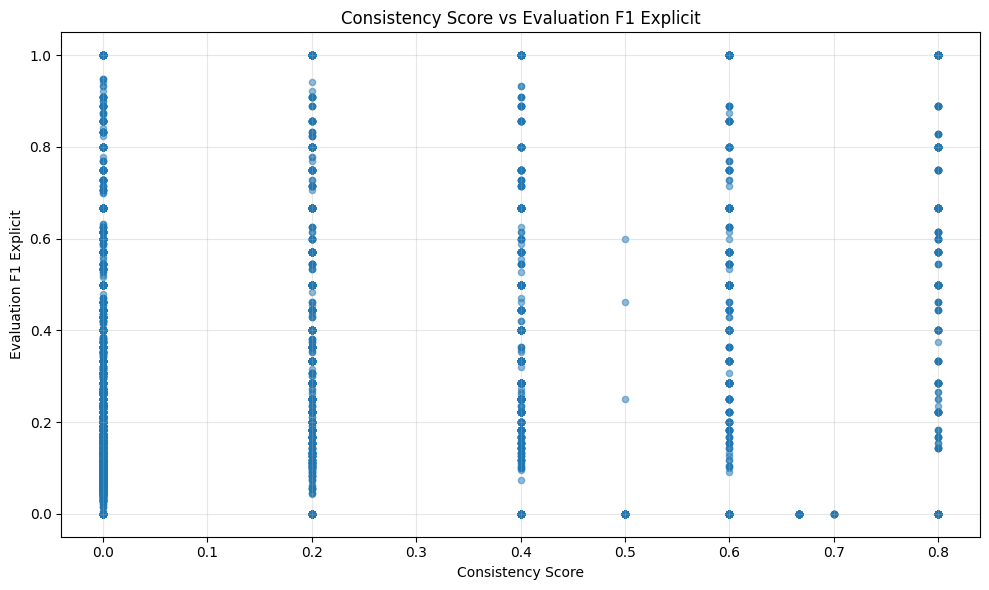

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(explicit_answers['consistency_score'], explicit_answers['evaluation_f1_explicit'], 
            alpha=0.5, s=20)
plt.xlabel('Consistency Score')
plt.ylabel('Evaluation F1 Explicit')
plt.title('Consistency Score vs Evaluation F1 Explicit')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
zero_f1_records_high_views = zero_f1_records[zero_f1_records['views'] > 500000]
print(f"Number of records with F1 score of 0 and views > 500000: {len(zero_f1_records_high_views)}")
print("\nSample records:")
print(zero_f1_records_high_views[['question', 'generated_answer', 'answer', 'evaluation_f1', 'event_year', 'views']].head(20))

Number of records with F1 score of 0 and views > 500000: 808

Sample records:
                                              question    generated_answer  \
101  who was the runner-up of the World Snooker Cha...         Mark Selby.   
105  who was the runner-up of the World Snooker Cha...         Mark Selby.   
106  who was the winner of the World Snooker Champi...  Ronnie O'Sullivan.   
108  who was the winner of the World Snooker Champi...  Ronnie O'Sullivan.   
109  who was the runner-up of the World Snooker Cha...         Mark Selby.   
170  what was the nationality of the World Chess Ch...            Russian.   
172  what was the nationality of the World Chess Ch...            Russian.   
174  what was the nationality of the World Chess Ch...            Russian.   
175     who was the World Chess Championship champion?     Magnus Carlsen.   
176  what was the nationality of the World Chess Ch...            Russian.   
177     who was the World Chess Championship champion?     Magnu

In [21]:
zero_f1_records.columns

Index(['event_year', 'event_date', 'subject', 'relationship', 'answer',
       'question', 'raw_content', 'parse_error', 'event', 'eventLabel', 'url',
       'success', 'title', 'content', 'error', 'content_length',
       'wikipedia_url_id', 'views', 'new_question', 'categories',
       'relative_question', 'id', 'prompt', 'generated_answer',
       'evaluation_f1'],
      dtype='object')

In [20]:
zero_f1_records.to_json('./chronosalign_output/zero_f1_records.json', orient='records', indent=2)

In [11]:
import pandas as pd
zero_f1_records = pd.read_json('./chronosalign_output/zero_f1_records.json')
unique_new_questions = zero_f1_records['new_question'].unique()
explicit_questions_df = pd.DataFrame({'new_question': unique_new_questions})

explicit_questions_df['prompt'] = explicit_questions_df['new_question'].map(
    lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue. 
    Question: In 2024, {x} Answer:"""
)

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch
from transformers import pipeline

## Generate answers

# Load model and tokenizer
model_name = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(save_path)
config = AutoConfig.from_pretrained(save_path)
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    cache_dir=hugging_face_cache_dir,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    config=config
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.bfloat16
)
def generate_answers(df, prompt_column):
    generated_answers = []
    for question in df[prompt_column]:
        result = generator(
            question, 
            max_new_tokens=10, 
            temperature=0.1, 
            do_sample=True, 
            eos_token_id=tokenizer.encode('\n', add_special_tokens=False)[0]
        )
        answer = result[0]['generated_text'][len(question):].strip()
        generated_answers.append(answer)
    return generated_answers

generated_answers = generate_answers(explicit_questions_df, 'prompt')
explicit_questions_df['generated_answer'] = generated_answers
print(f"Generated {len(generated_answers)} answers")
explicit_questions_df.to_json('./chronosalign_output/explicit_questions_with_answers.json', orient='records', indent=2)


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Generated 13057 answers


In [14]:
tokenizer = AutoTokenizer.from_pretrained(save_path)

eval_dataset = evaluation_dataset(
    dataset_path='./chronosalign_output/explicit_questions_with_answers.json',
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

In [ ]:
eval_dataset.get_evaluation('generated_answer')

In [19]:
# Count unique questions per category
questions_per_category = dataset_df.groupby('categories')['question'].nunique().sort_values(ascending=False)

print("Unique questions per category:")
print(questions_per_category)
print(f"\nTotal unique questions: {questions_per_category.sum()}")

Unique questions per category:
categories
sport       7289
culture     6205
politics     180
Name: question, dtype: int64

Total unique questions: 13674


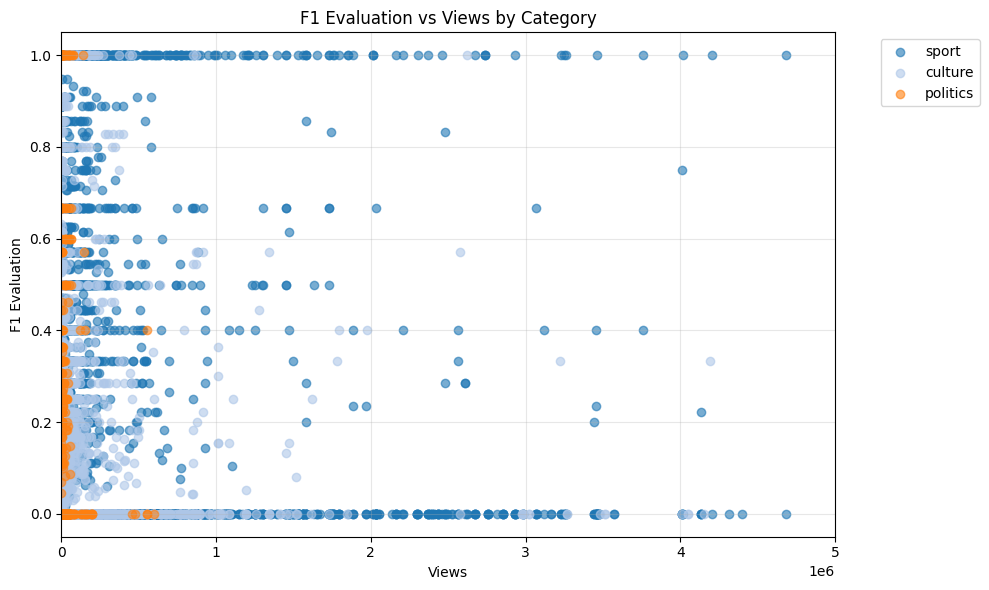

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Get unique categories and assign colors
categories = dataset_df['categories'].unique()
colors = plt.cm.tab20(range(len(categories)))

# Plot each category with a different color
for category, color in zip(categories, colors):
    mask = dataset_df['categories'] == category
    plt.scatter(dataset_df[mask]['views'], dataset_df[mask]['evaluation_f1'], 
                alpha=0.6, label=category, color=color)

plt.xlabel('Views')
plt.ylabel('F1 Evaluation')
plt.title('F1 Evaluation vs Views by Category')
plt.xlim(0, 5000000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
